In [6]:
def write_pointcloud(filename,xyz_points,rgb_points=None):

    """ creates a .pkl file of the point clouds generated
    """

    assert xyz_points.shape[1] == 3,'Input XYZ points should be Nx3 float array'
    if rgb_points is None:
        rgb_points = np.ones(xyz_points.shape).astype(np.uint8)*255
    assert xyz_points.shape == rgb_points.shape,'Input RGB colors should be Nx3 float array and have same size as input XYZ points'

    # Write header of .ply file
    fid = open(filename,'wb')
    fid.write(bytes('ply\n', 'utf-8'))
    fid.write(bytes('format binary_little_endian 1.0\n', 'utf-8'))
    fid.write(bytes('element vertex %d\n'%xyz_points.shape[0], 'utf-8'))
    fid.write(bytes('property float x\n', 'utf-8'))
    fid.write(bytes('property float y\n', 'utf-8'))
    fid.write(bytes('property float z\n', 'utf-8'))
    fid.write(bytes('property float red\n', 'utf-8'))
    fid.write(bytes('property float green\n', 'utf-8'))
    fid.write(bytes('property float blue\n', 'utf-8'))
    fid.write(bytes('end_header\n', 'utf-8'))

    # Write 3D points to .ply file
    for i in range(xyz_points.shape[0]):
#         fid.write(bytearray(struct.pack("fffccc",xyz_points[i,0],xyz_points[i,1],xyz_points[i,2],
#                                         rgb_points[i,0].tostring(),rgb_points[i,1].tostring(),
#                                         rgb_points[i,2].tostring())))
        
       
        fid.write(bytearray(struct.pack("ffffff",xyz_points[i,0],xyz_points[i,1],xyz_points[i,2],
                                        rgb_points[i,0],rgb_points[i,1],rgb_points[i,2])))
        
    fid.close()

## Not using deep learning algorithm but identify the lane marking by looking at the intensity value

In [7]:
import numpy as np
import pandas as pd
#import geopandas as gp
import matplotlib.pyplot as plt
import time


In [8]:
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.cluster import Birch
from sklearn.cluster import MeanShift
from sklearn.cluster import OPTICS


In [3]:
!pip install sklearn
!pip install scipy

In [9]:
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from scipy.spatial.distance import squareform
from sklearn import linear_model
import struct

In [5]:
!pip install open3d

In [6]:
import open3d as o3d


ImportError: libGL.so.1: cannot open shared object file: No such file or directory

+ The intensity of each LIDAR point should contain enough information to recover the lane marking from the flat surface since the lane marking should have a higher intensity compared to the plain asphalt or concrete of the street. 

23
22
23
19
17
19
25
21
22
20
14
16
16
18
21
23
23
23
11
24
25


<ipython-input-17-411485343668>:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


31


<ipython-input-17-411485343668>:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


20


...

<ipython-input-17-411485343668>:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


24


<ipython-input-17-411485343668>:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  plt.figure()


21


KeyboardInterrupt: 

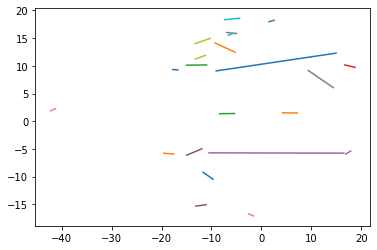

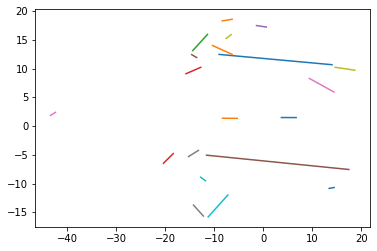

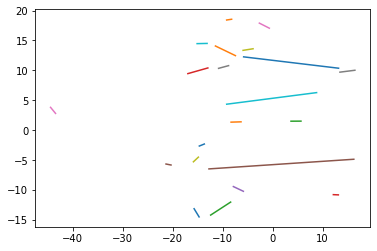

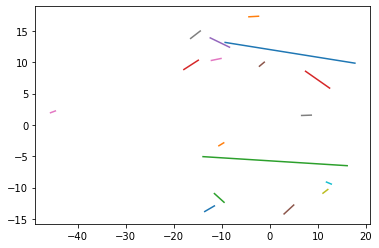

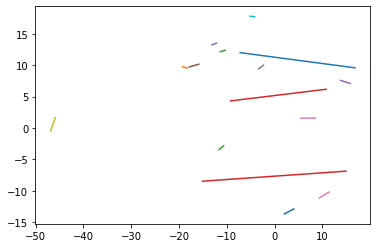

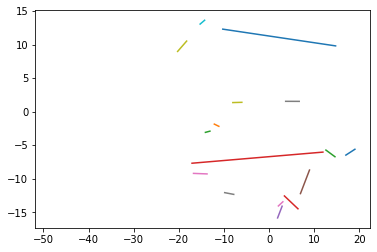

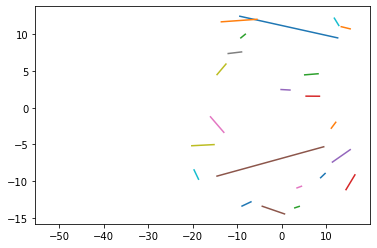

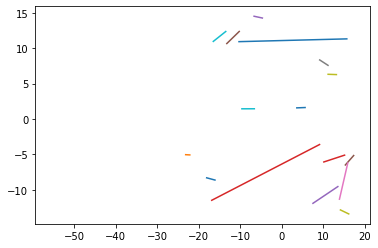

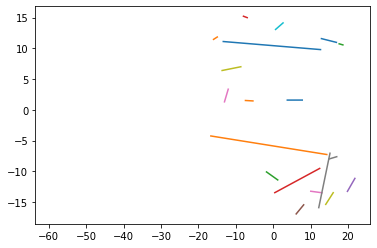

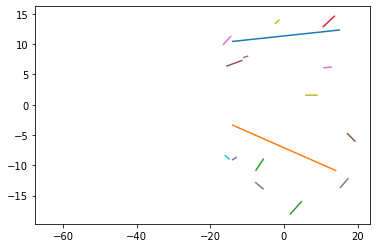

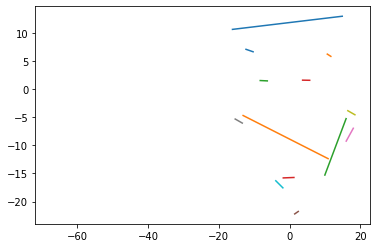

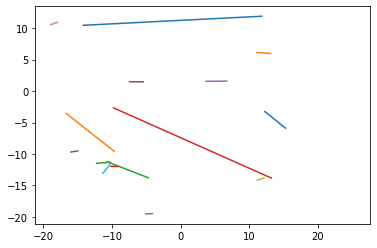

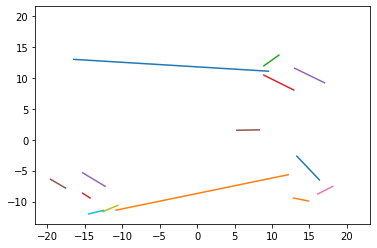

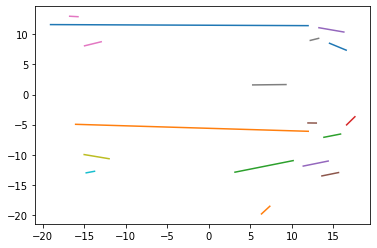

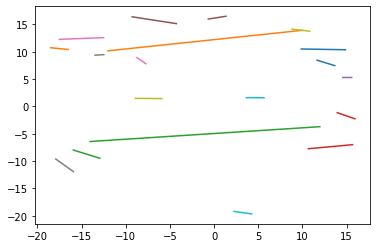

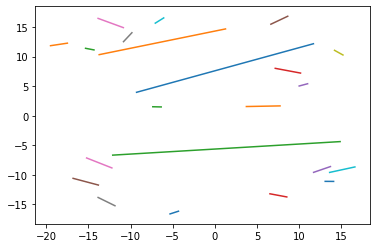

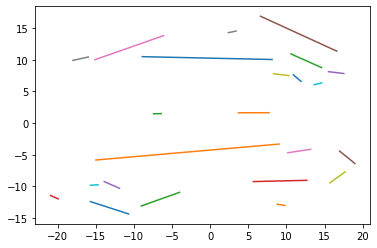

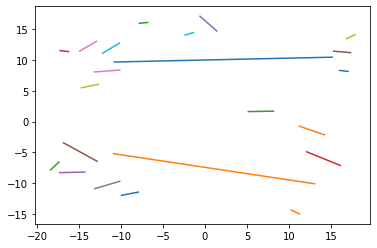

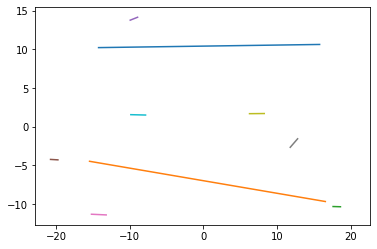

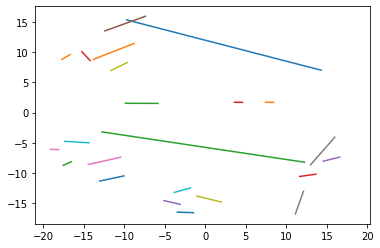

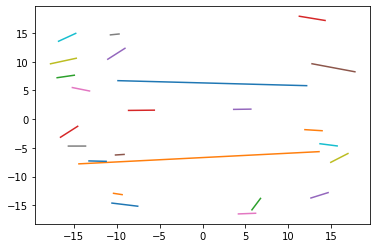

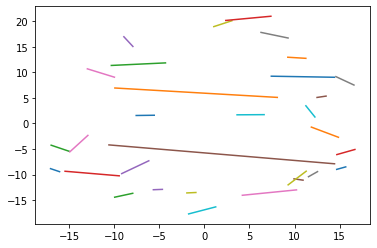

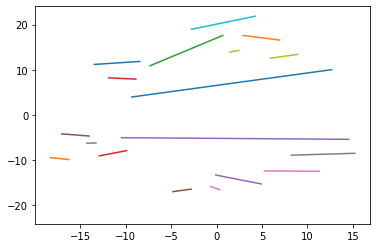

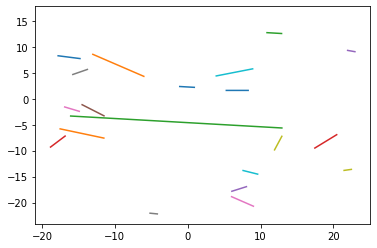

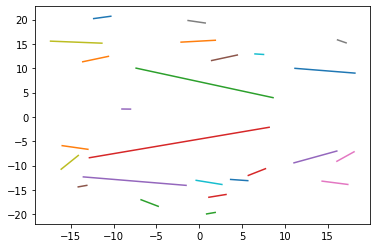

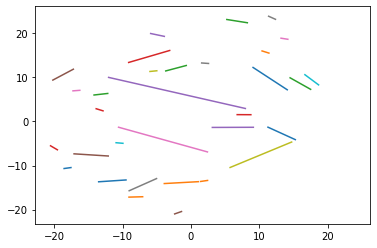

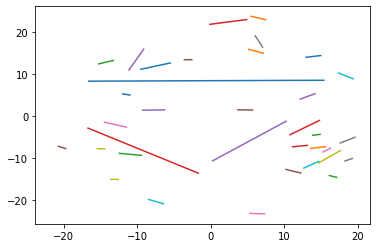

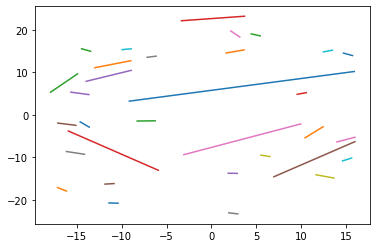

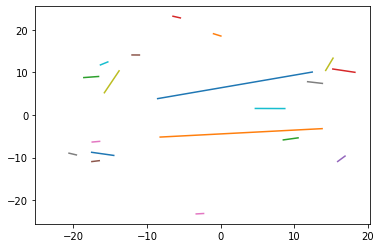

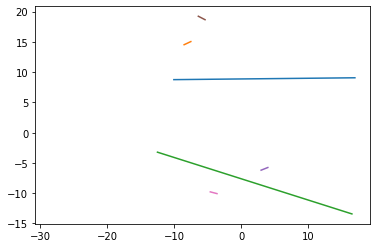

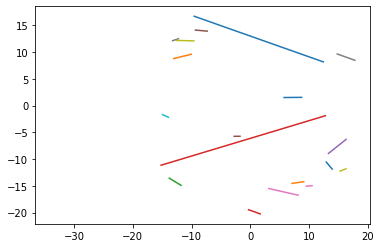

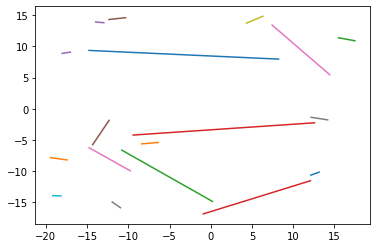

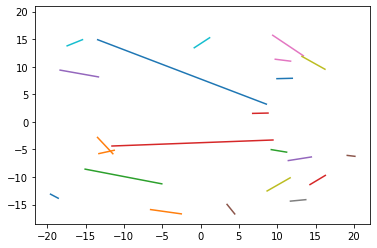

In [17]:
for index in range(0,188):
    data=[]
    try:
        with open('./0926_0027/output_{}.txt'.format(index)) as f:
            line = f.readline()
            while line:
                d=line.split()
                tmp=[]
                for i in d:
                    tmp.append(float(i)) # convert string to float
                data.append(tmp)
                line=f.readline()
    except:
        continue
         
    a=np.array(data)

    ### assumption: There's no void space line in txt file.
    ### intensity: 0~255
    pointcloud_df = pd.DataFrame()
    pointcloud_df["Latitude"] = a[:,0]
    pointcloud_df["Longitude"] = a[:,1]
    pointcloud_df["Altitude"] = a[:,2]
    i = a[:,3]*255
    ii=[]
    for x in i:
        ii.append(int(x))
    pointcloud_df["Intensity"] = ii

    def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
        pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
        pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
        pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
        pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])

        pointcloud_df["Easting"] = pointcloud_df["Latitude"]
        pointcloud_df["Northing"] = pointcloud_df["Longitude"]
        return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

    pointcloud_df["Easting"] = pointcloud_df["Latitude"]
    pointcloud_df["Northing"] = pointcloud_df["Longitude"]
    xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]

    def filter_by_mean_value(pointcloud_df):

        mean = pointcloud_df["Intensity"].mean()
        std = pointcloud_df["Intensity"].std()

        lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
        lanes_df = lanes_df[lanes_df["Intensity"] < mean + 7 * std ]

#         print("MEAN FILTER:")
#         print("============")
#         print("Intensity - Mean value:      ", mean)
#         print("Intensity - Std value:       ", std)
#         print("Intensity - Lower bound:     ", mean + 1 * std)
#         print("Intensity - Upper bound:     ", mean + 9 * std)
#         print("Intensity - Filtered points: ", len(lanes_df))
#         print("Intensity - Original points: ", len(pointcloud_df))
#         print("Intensity - Reduction to %:  ", len(lanes_df)/len(pointcloud_df))

        return lanes_df

    lanes_df = xyzi_df.copy()
    lanes_df = filter_by_mean_value(lanes_df)
    b = np.array(lanes_df)
    bb = np.vstack((b[:,0], b[:,1],b[:,2]))
    bb= bb.T
    #write_pointcloud("./original_lane_{}.ply".format(index),bb)
    
    X = lanes_df[["Easting", "Northing", "Altitude"]].values

    db = DBSCAN(eps=1, min_samples=30).fit(X)

    labels = db.labels_
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)
    
    lanes_df["Group"] = labels
    cluster_df = lanes_df[["Easting", "Northing", "Altitude", "Group"]]
    cluster_df = cluster_df[cluster_df["Group"]>=0]
    #cluster_df.to_csv("./clustering.xyz",index=False
    b = np.array(cluster_df)
    bb = np.vstack((b[:,0], b[:,1],b[:,2]))
    bb= bb.T
    #write_pointcloud("./original_cluster_{}.ply".format(index),bb)
    
    
    ransac = linear_model.RANSACRegressor()
    ransaclines = []
    #print("START")
    print(n_clusters_)
    for cluster in range(n_clusters_):
        #print(cluster)
        sub_cluster_df = cluster_df[cluster_df["Group"] == cluster]
        Xpoints = sub_cluster_df[["Easting"]].values
        Ypoints = sub_cluster_df[["Northing"]].values
        ransac.fit(Xpoints, Ypoints)
        line_X = np.arange(Xpoints.min(), Xpoints.max())[:, np.newaxis]
        line_y_ransac = ransac.predict(line_X)

        ransaclines.append([line_X,line_y_ransac])
        
    plt.figure()
    for l in ransaclines:
        plt.plot(l[0],l[1])    
        
    #plt.savefig('savelanefig_{}.png'.format(index))


0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6678   19.844999
6679   19.826000
7031   18.740000
7032   18.719000
7033   18.643000
...          ...
16250  -0.766000
16251  -0.793000
16252  -0.832000
16253  -0.846000
16254  -0.876000

[712 rows x 1 columns]
2
         Easting
6676   19.013000
6677   19.204000
7028   17.954000
7029   17.934000
7030   17.976999
...          ...
15604   4.295000
15987   4.243000
15988   4.248000
15989   4.233000
15990   4.206000

[274 rows x 1 columns]
3
       Easting
117     -4.058
118     -4.051
119     -4.057
120     -4.051
121     -3.995
...        ...
15694   -0.662
15695   -0.686
15697   -0.790
15698   -0.822
15700   -0.879

[1001 rows x 1 columns]


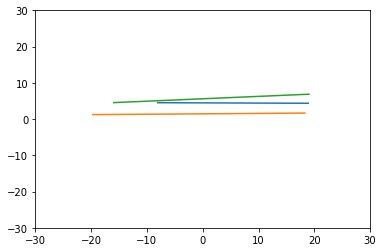

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6849   19.851999
6850   19.917999
6851   19.773001
7244   18.733000
7245   18.705999
...          ...
16526  -0.882000
16527  -0.901000
16528  -0.929000
16529  -0.970000
16607  -0.041000

[752 rows x 1 columns]
2
         Easting
6848   19.091999
7241   17.969999
7242   17.947001
7243   18.176001
7745   17.014000
...          ...
16798   3.708000
16799   3.712000
16800   3.712000
16801   3.684000
16802   3.691000

[304 rows x 1 columns]
3
       Easting
150     -5.242
151     -5.096
152     -5.105
153     -5.098
154     -5.095
...        ...
15937   -0.642
15938   -0.674
15939   -0.744
15941   -0.904
15942   -0.934

[1056 rows x 1 columns]


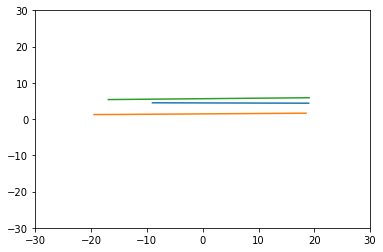

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
4988   19.187000
5302   19.149000
5654   18.815001
5655   18.816999
5656   18.792000
...          ...
16610  -0.957000
16611  -0.982000
16715   0.014000
16716  -0.150000
16717  -0.212000

[784 rows x 1 columns]
2
         Easting
4987   19.129000
5650   18.858000
5651   18.849001
5652   18.840000
5653   18.827999
...          ...
16902   3.716000
16903   3.708000
16904   3.700000
16905   3.694000
16906   3.677000

[292 rows x 1 columns]
3
       Easting
143     -6.272
144     -6.213
145     -6.209
146     -6.215
147     -6.221
...        ...
15796   -1.450
16019    0.501
16035   -0.013
16036   -0.163
16045   -0.494

[1075 rows x 1 columns]


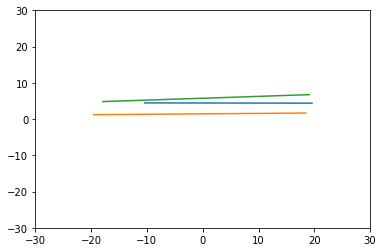

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
6127    16.372
6396    15.909
6397    15.924
6398    15.912
6822    15.903
...        ...
16639   -0.281
16640   -0.315
16641   -0.391
16642   -0.434
16643   -0.507

[775 rows x 1 columns]
2
         Easting
5652   16.368000
6126   16.306999
6390   15.997000
6391   15.986000
6392   15.977000
...          ...
16835   3.696000
16836   3.707000
16837   3.697000
16838   3.674000
16839   3.726000

[248 rows x 1 columns]
3
       Easting
131     -7.429
132     -7.336
133     -7.335
134     -7.338
135     -7.341
...        ...
15936   -0.529
15937   -0.560
15938   -0.594
15939   -0.619
15942   -0.749

[1107 rows x 1 columns]


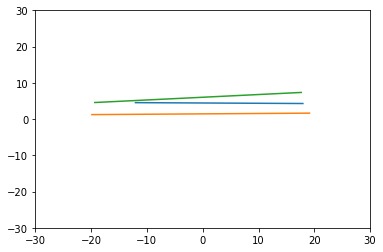

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
6378    13.553
6886    13.400
6887    13.519
7806    13.023
7807    13.019
...        ...
16494   -0.365
16495   -0.397
16496   -0.428
16497   -0.438
16498   -0.479

[774 rows x 1 columns]
2
         Easting
6377   13.556000
6785   19.559999
6786   13.426000
6882   18.327000
6883   18.301001
...          ...
15290  -5.473000
15291  -5.478000
15328  -5.315000
15329  -5.322000
15330  -5.308000

[190 rows x 1 columns]
3
       Easting
137     -8.495
138     -8.490
139     -8.494
140     -8.503
141     -8.499
...        ...
15845   -0.522
15848   -0.640
15849   -0.674
15850   -0.704
15851   -0.725

[1150 rows x 1 columns]


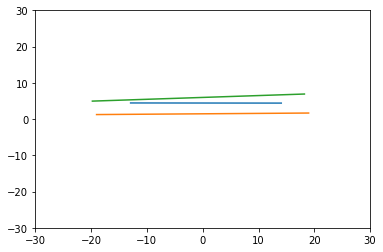

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
9744   -14.837
9745   -14.841
9746   -14.909
10281  -14.059
10282  -14.063
...        ...
16068   -0.636
16069   -0.667
16070   -0.681
16071   -0.693
16072   -0.710

[809 rows x 1 columns]
2
         Easting
6519   18.374001
6520   18.368999
6902   17.344999
6903   17.273001
7429   16.438000
...          ...
16248   3.702000
16249   3.711000
16250   3.698000
16251   3.689000
16252   3.670000

[316 rows x 1 columns]
3
       Easting
152    -11.068
153    -10.825
154    -10.817
155    -10.784
156    -10.802
...        ...
15333    0.089
15334    0.058
15335    0.034
15341   -0.170
15357   -0.774

[1094 rows x 1 columns]


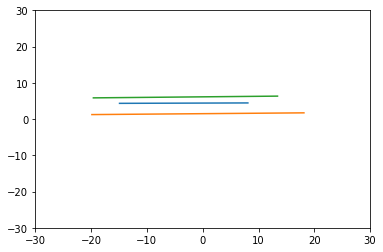

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6537   19.622000
6538   19.607000
6948   18.417000
6949   18.474001
7505   17.378000
...          ...
16597  -0.709000
16598  -0.727000
16599  -0.767000
16600  -0.780000
16601  -0.809000

[515 rows x 1 columns]
2
         Easting
6535   18.971001
6536   18.958000
6945   17.867001
6946   17.834000
6947   18.035000
...          ...
16860   0.220000
16861   0.200000
16862   0.185000
16863   0.161000
16864   0.113000

[425 rows x 1 columns]
3
       Easting
179    -14.443
180    -14.423
181    -14.412
182    -14.426
183    -14.435
...        ...
15846   -0.779
15847   -0.813
15848   -0.848
15849   -0.874
15850   -0.894

[947 rows x 1 columns]


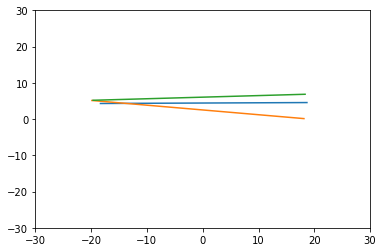

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6565   18.802999
6566   18.746000
7066   17.709000
7067   17.893000
7205  -17.245001
...          ...
16898  -0.605000
16899  -0.634000
16900  -0.642000
16901  -0.676000
16902  -0.760000

[904 rows x 1 columns]
2
         Easting
6804  -19.249001
6805  -19.299000
7064   17.266001
7065   17.309000
7208  -18.101000
...          ...
17101   3.683000
17102   3.691000
17103   3.676000
17104   3.661000
17105   3.662000

[361 rows x 1 columns]
3
         Easting
162   -18.280001
163   -18.243999
164   -18.143000
165   -18.141001
166   -18.153000
...          ...
15767  -1.158000
15768  -1.219000
15769  -1.250000
15770  -1.285000
15771  -1.302000

[1214 rows x 1 columns]


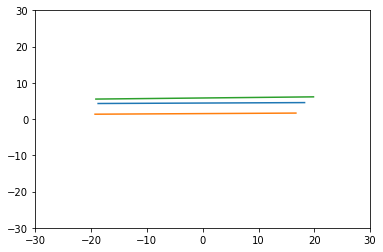

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
6232   -12.328
6567    19.914
6757   -12.364
6758   -12.360
6759   -12.374
...        ...
17589   -0.802
17590   -0.812
17591   -0.828
17592   -0.886
17593   -1.444

[954 rows x 1 columns]
2
       Easting
4489   -12.591
4789   -12.699
4790   -12.693
6233   -12.419
6489   -12.285
...        ...
17205    3.948
17206    3.950
17207    3.942
17263    3.852
17479    3.751

[318 rows x 1 columns]
3
         Easting
5735   19.306000
6018   19.756001
6020   16.763000
6446   19.856001
6447   19.884001
...          ...
16416  -1.155000
16417  -1.189000
16419  -1.275000
16722   0.382000
16723   0.350000

[1083 rows x 1 columns]


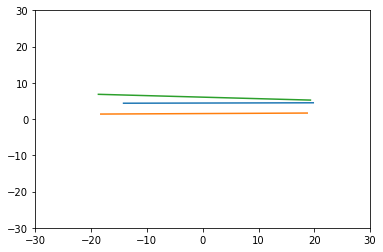

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6395   19.957001
6798   18.752001
6799   18.707001
6800   18.657000
7336   17.681999
...          ...
16576  -0.948000
16577  -0.950000
16578  -0.982000
16579  -1.067000
16784   0.037000

[846 rows x 1 columns]
2
         Easting
6393   19.336000
6394   19.288000
6795   18.205999
6796   18.174999
6797   18.360001
...          ...
16779   3.697000
16780   3.701000
16781   3.694000
16782   3.689000
16783   3.666000

[193 rows x 1 columns]
3
       Easting
5121    19.955
5309    -7.080
5858    18.987
5859    17.400
6321   -15.445
...        ...
15824   -0.924
15825   -0.954
15826   -1.079
15828   -1.172
15829   -1.227

[961 rows x 1 columns]


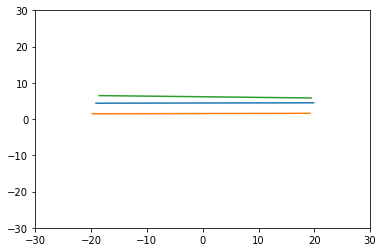

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6932   19.947001
6933   19.924999
7334   18.721001
7335   18.664000
7893   17.653000
...          ...
16594  -0.937000
16595  -0.941000
16766  -0.078000
16767  -0.173000
16768  -0.288000

[810 rows x 1 columns]
2
         Easting
7891   17.083000
7892   17.118000
8054  -18.917000
8055  -18.875999
8241   16.153000
...          ...
16761   3.704000
16762   3.703000
16763   3.696000
16764   3.699000
16765   3.669000

[272 rows x 1 columns]
3
         Easting
5791  -10.596000
5792  -10.649000
5793  -11.185000
5794  -11.250000
5801  -18.674999
...          ...
15919  -0.923000
15921  -0.979000
15924  -1.084000
15925  -1.130000
15926  -1.162000

[799 rows x 1 columns]


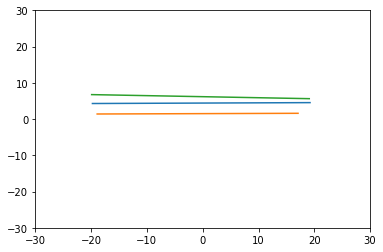

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
7538   18.983999
7539   18.905001
8090   17.862000
8091   17.917000
8251  -19.924000
...          ...
16932  -0.878000
16933  -0.903000
16934  -0.909000
16935  -0.951000
17112  -0.112000

[813 rows x 1 columns]
2
         Easting
7116   19.434000
7117   19.632999
7536   18.253000
7537   18.195000
8088   17.240000
...          ...
17107   3.721000
17108   3.721000
17109   3.711000
17110   3.696000
17111   3.739000

[279 rows x 1 columns]
3
       Easting
5095   -15.338
5467   -15.244
5914   -15.045
6312   -15.514
6711   -14.678
...        ...
16198   -0.585
16199   -0.636
16200   -0.738
16202   -0.812
16487    0.204

[750 rows x 1 columns]


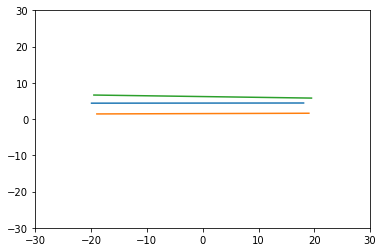

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
7483   19.044001
7484   18.995001
7485   19.103001
8075   17.871000
8076   17.952999
...          ...
17763  -0.058000
17764  -0.112000
17765  -0.207000
17766  -0.289000
17767  -0.362000

[865 rows x 1 columns]
2
         Easting
7051   19.350000
7052   19.318001
7053   19.493000
7480   18.202000
7481   18.167000
...          ...
15715   5.333000
15716   5.313000
15908  -5.578000
16199  -5.407000
16200  -5.407000

[182 rows x 1 columns]
3
         Easting
6241  -19.427000
6643  -19.372000
6644  -19.933001
6646  -19.605000
6917   18.003000
...          ...
16818  -0.794000
16819  -0.828000
16820  -0.849000
16822  -0.913000
16828  -1.092000

[851 rows x 1 columns]


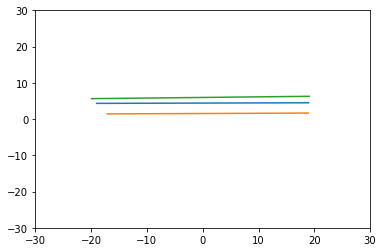

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6871   19.013000
6872   18.995001
6873   18.913000
7416   17.912001
7417   17.895000
...          ...
16979  -0.934000
16980  -0.942000
16981  -0.976000
16982  -0.979000
17177  -0.037000

[850 rows x 1 columns]
2
         Easting
6467   19.181999
6468   19.129999
6469   19.236000
6868   18.062000
6869   18.047001
...          ...
15007   5.292000
15209  -5.601000
15210  -5.651000
15508  -5.415000
15509  -5.437000

[180 rows x 1 columns]
3
         Easting
4115   18.084000
4116   17.966999
4398   18.141001
4399   18.125999
4741   18.009001
...          ...
16212  -0.803000
16213  -0.837000
16214  -0.866000
16215  -0.890000
16216  -0.968000

[854 rows x 1 columns]


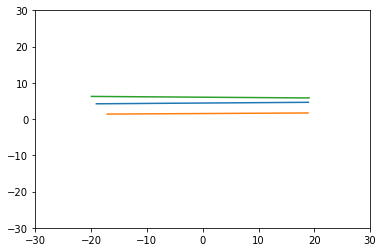

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6421   19.962000
6820   19.059000
6821   19.052999
6822   18.971001
7364   17.958000
...          ...
16912  -0.798000
16913  -0.815000
16914  -0.823000
16915  -0.842000
16916  -0.958000

[850 rows x 1 columns]
2
         Easting
6817   18.009001
6818   17.978001
6819   18.207001
7362   17.052999
7363   17.025999
...          ...
17142   3.674000
17143   3.682000
17144   3.667000
17145   3.646000
17146   3.647000

[291 rows x 1 columns]
3
       Easting
4736    15.122
4737    15.108
4738    15.138
5087    15.206
5088    15.197
...        ...
16105   -0.938
16106   -0.966
16107   -1.005
16108   -1.055
16109   -1.080

[851 rows x 1 columns]


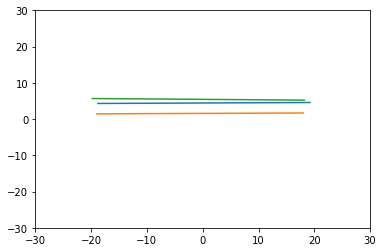

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6185   19.693001
6186   19.643000
6187   19.416000
6583   18.535999
6584   18.493999
...          ...
16741  -0.700000
16742  -0.708000
16743  -0.748000
16744  -0.758000
16745  -0.766000

[905 rows x 1 columns]
2
         Easting
6065   19.875000
6183   18.620001
6184   18.652000
6580   17.597000
6581   17.568001
...          ...
16398   3.964000
16399   3.962000
16400   3.949000
16401   3.931000
16648   3.747000

[245 rows x 1 columns]
3
       Easting
5656    17.007
5661    10.643
5662    10.626
6066    19.910
6067    19.729
...        ...
15667   -0.957
15668   -0.983
15946    0.042
15957   -0.370
15958   -0.396

[708 rows x 1 columns]


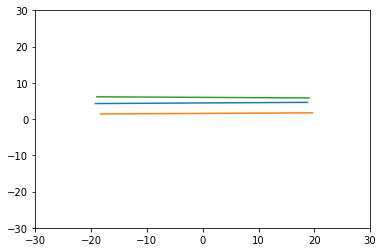

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6268   19.952999
6269   19.987000
6635   18.777000
6636   18.724001
6637   18.902000
...          ...
16938  -0.294000
16939  -0.305000
16940  -0.333000
16941  -0.368000
16942  -0.409000

[881 rows x 1 columns]
2
         Easting
6266   18.999001
6267   18.966000
6632   17.903999
6633   17.871000
6634   18.030001
...          ...
16897   3.788000
16898   3.768000
16899   3.768000
16900   3.779000
17134   3.702000

[274 rows x 1 columns]
3
         Easting
5032   19.636000
5463   19.466999
5747   19.459999
5748   19.334999
5749   19.259001
...          ...
16154  -0.425000
16156  -0.487000
16157  -0.512000
16158  -0.544000
16160  -0.598000

[785 rows x 1 columns]


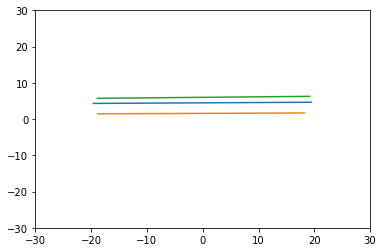

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6773   19.540001
6774   19.587999
7168   18.419001
7169   18.371000
7170   18.341000
...          ...
18133  -1.088000
18268   0.200000
18269  -0.035000
18270  -0.125000
18271  -0.352000

[936 rows x 1 columns]
2
         Easting
6771   18.724001
6772   18.683001
7165   17.656000
7166   17.629000
7167   17.770000
...          ...
16748   5.167000
16765  -5.374000
16766  -5.387000
16767  -5.401000
18267   3.730000

[182 rows x 1 columns]
3
         Easting
5089   19.632999
5090   19.584000
5091   19.188000
5092   18.702000
5464   19.205000
...          ...
17522  -0.481000
17524  -0.585000
17526  -0.654000
17531  -0.805000
17534  -0.896000

[883 rows x 1 columns]


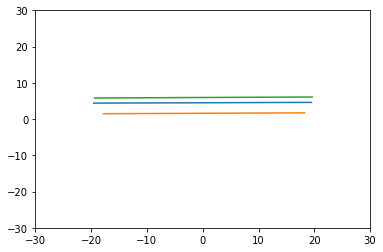

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6720   19.431000
6721   19.497999
7136   18.275000
7137   18.202999
7697   17.287001
...          ...
17946  -0.904000
17947  -0.913000
17948  -0.943000
17949  -0.965000
17950  -0.992000

[923 rows x 1 columns]
2
         Easting
6718   18.767000
6719   18.726000
7387  -19.931999
7388  -19.973000
8058   15.844000
...          ...
18276   3.664000
18277   3.652000
18278   3.642000
18279   3.625000
18280   3.623000

[226 rows x 1 columns]
3
         Easting
5354   18.271999
5360   14.564000
5832   18.389999
5833   14.977000
5834   16.309000
...          ...
17272  -0.427000
17273  -0.461000
17274  -0.481000
17275  -0.511000
17280  -0.679000

[1077 rows x 1 columns]


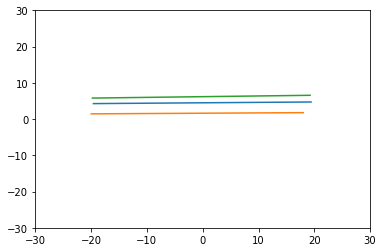

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6462   19.427999
6463   19.587000
6878   18.253000
6879   18.215000
6880   18.218000
...          ...
17844  -0.766000
17845  -0.778000
17846  -0.812000
17847  -0.839000
17848  -0.891000

[885 rows x 1 columns]
2
         Easting
7152  -19.858999
7153  -19.794001
7476   17.957001
7477   16.808001
7478   16.823999
...          ...
18218   3.652000
18219   3.647000
18220   3.634000
18221   3.612000
18222   3.630000

[277 rows x 1 columns]
3
         Easting
2696    8.480000
2697    8.463000
5901   19.245001
5902   18.708000
6348   18.900000
...          ...
17167  -0.533000
17168  -0.568000
17169  -0.591000
17170  -0.614000
17171  -0.646000

[1255 rows x 1 columns]


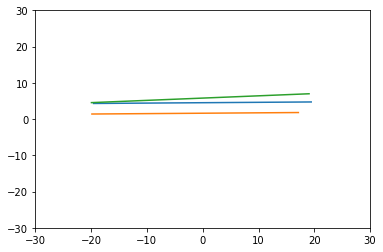

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
487    19.999001
2798   18.976999
3216   18.995001
3217   19.059999
3568   19.292000
...          ...
17101  -0.754000
17102  -0.768000
17103  -0.781000
17104  -0.807000
17105  -0.844000

[875 rows x 1 columns]
2
         Easting
3213   19.104000
3214   19.089001
3215   19.045000
3565   19.344000
3566   19.226000
...          ...
17437   3.650000
17438   3.653000
17439   3.650000
17440   3.647000
17441   3.630000

[289 rows x 1 columns]
3
         Easting
0      15.826000
1      15.771000
2      16.695999
287    15.764000
288    15.852000
...          ...
16444  -0.336000
16449  -0.486000
16452  -0.558000
16463  -0.856000
16464  -0.903000

[1410 rows x 1 columns]


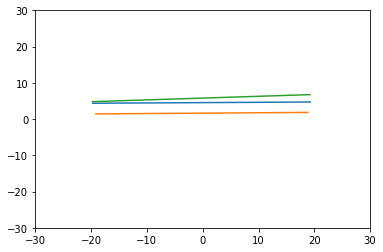

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
2057    12.195
4527    11.499
4528    11.517
4529    11.585
4926    11.746
...        ...
16855   -0.795
16856   -0.824
16857   -0.839
16858   -0.875
16859   -0.891

[852 rows x 1 columns]
2
       Easting
0       13.382
1000    13.448
1919    12.162
2674    12.310
2675    11.910
...        ...
17190    3.657
17191    3.650
17192    3.641
17193    3.623
17194    3.626

[289 rows x 1 columns]
3
       Easting
2       10.923
3       10.849
273     10.857
274     11.703
456     10.910
...        ...
16227   -0.907
16228   -0.938
16229   -0.961
16230   -0.996
16231   -1.043

[1433 rows x 1 columns]


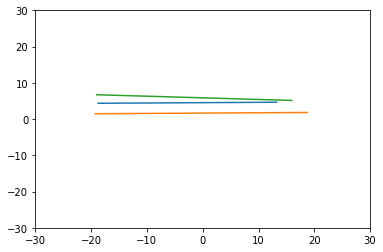

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
7035  -19.252001
7036  -19.247000
7257    6.446000
7442  -18.549999
7443  -18.233000
...          ...
16752  -0.801000
16753  -0.831000
16754  -0.842000
16755  -0.859000
16756  -0.900000

[870 rows x 1 columns]
2
       Easting
0        8.941
1        8.262
638      8.173
639      8.154
640      8.239
...        ...
17115    3.658
17116    3.653
17117    3.646
17118    3.651
17119    3.626

[170 rows x 1 columns]
3
       Easting
5        7.634
6        7.577
642      8.901
643      7.451
798      7.467
...        ...
16074    0.334
16075    0.303
16076    0.272
16077    0.247
16078    0.215

[1238 rows x 1 columns]


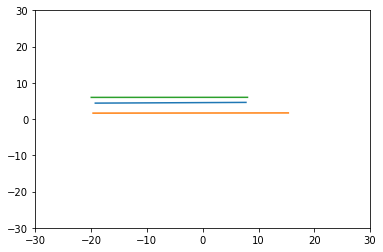

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
4594   19.165001
4595   19.222000
4596   19.065001
4597   19.160000
4964   18.041000
...          ...
14426   3.924000
14427   3.920000
16487   3.002000
16488   2.975000
16489   2.956000

[338 rows x 1 columns]
2
       Easting
21      -1.043
22      -1.059
338      1.377
339      0.990
340      0.551
...        ...
16776    0.041
16777    0.037
16778    0.030
16779    0.022
16780    0.015

[403 rows x 1 columns]
3
         Easting
4115  -18.731001
4116  -18.539000
4480  -18.319000
4598   19.650000
4599   19.785999
...          ...
12611   4.566000
12980   4.828000
12981   4.795000
12982   4.703000
12983   4.564000

[504 rows x 1 columns]


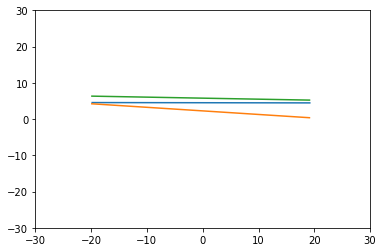

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
2262   -5.409000
4724   19.257000
4725   19.193001
5052   18.121000
5053   18.042000
...          ...
15061  -1.956000
15280   2.893000
15281   0.168000
15282   0.120000
15283  -0.888000

[961 rows x 1 columns]
2
       Easting
281    -10.233
601     -5.364
602     -5.370
603     -5.368
604     -5.342
...        ...
15275    3.680
15276    3.682
15277    3.679
15278    3.657
15279    3.644

[249 rows x 1 columns]
3
       Easting
67      -3.102
68      -3.104
71      -3.599
74      -3.710
75      -3.695
...        ...
14150    0.621
14151    0.588
14152    0.565
14153    0.533
14154    0.502

[999 rows x 1 columns]


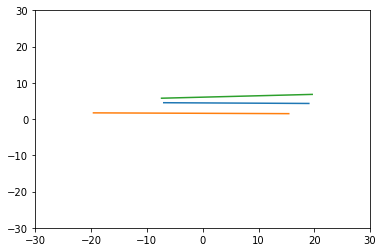

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
2607   -13.435
2927   -13.431
3072    18.909
3212   -13.319
3456   -13.417
...        ...
14654   -0.064
14655   -0.085
14656   -0.098
14657   -0.139
14658   -0.261

[889 rows x 1 columns]
2
       Easting
868    -13.388
869    -13.393
1088   -13.517
1089   -13.512
1090   -13.612
...        ...
11748    7.060
11749    7.047
11769    6.791
11770    6.787
11771    6.771

[151 rows x 1 columns]
3
       Easting
116     -7.957
117     -7.950
118     -7.981
119     -8.537
121     -8.627
...        ...
13735   -2.014
13736   -2.041
13915    0.224
13916   -0.060
13917   -0.179

[913 rows x 1 columns]


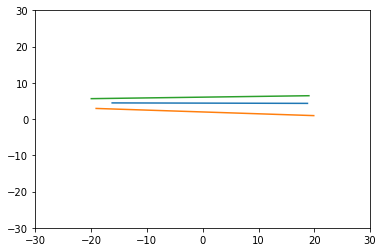

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6053   19.931999
6055   13.402000
6462   18.802999
6463   18.785999
6464   18.719999
...          ...
16247  -0.199000
16248  -0.232000
16249  -0.273000
16250  -0.334000
16251  -0.388000

[899 rows x 1 columns]
2
       Easting
6695   -19.837
6696   -19.777
7057    17.174
7058    17.219
7226   -18.670
...        ...
16226    3.720
16227    3.694
16228    3.709
16229    3.681
16230    3.675

[235 rows x 1 columns]
3
       Easting
141    -13.761
142    -13.817
143    -13.840
144    -13.841
145    -13.846
...        ...
15515   -2.271
15516   -2.409
15559   -1.484
15588    1.445
15626    0.933

[931 rows x 1 columns]


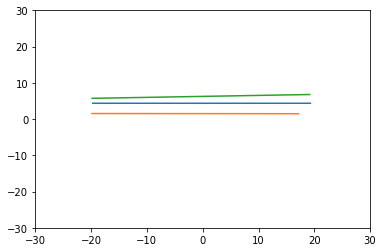

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5314  -14.477000
5782   18.853001
5783   18.900999
5784   18.756001
6326   17.757000
...          ...
14907  -0.557000
14908  -0.579000
14909  -0.590000
14910  -0.620000
14911  -0.632000

[914 rows x 1 columns]
2
         Easting
6325   18.368999
7996   14.154000
7997   14.152000
7998   14.236000
8407   13.427000
8408   13.422000
8409   13.388000
8609   12.998000
8610   12.979000
8611   12.973000
8612   13.025000
8613   12.922000
9184   12.452000
9185   12.437000
9186   12.427000
9187   12.457000
9686   12.565000
9687   12.558000
9688   12.551000
9689   11.409000
9690   11.410000
9691   11.404000
9763  -12.259000
9764  -12.262000
9765  -12.233000
9881   10.772000
9882   10.773000
9883   10.779000
9884   10.772000
9945  -11.530000
9946  -11.544000
9947  -11.523000
10041  10.238000
10042  10.226000
10043  10.227000
10044  10.219000
10045  10.220000
10115 -10.910000
10116 -10.922000
10117 -10.917000
10118 -10.906000
10251 -

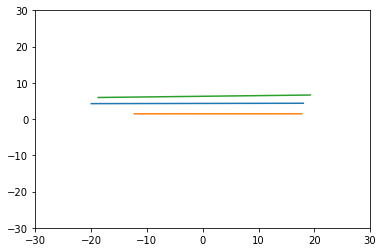

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
4416  -19.754999
5038   19.958000
5039   19.896000
5040   19.723000
5406   18.695999
...          ...
15415  -0.809000
15416  -0.838000
15417  -0.843000
15418  -0.871000
15419  -0.913000

[954 rows x 1 columns]
2
         Easting
5036   19.177999
5037   19.139999
5404   18.016001
5405   17.957001
5932   17.021000
...          ...
13830   4.925000
13831   4.930000
13832   4.920000
13869   4.741000
13870   4.721000

[153 rows x 1 columns]
3
         Easting
5041   19.893000
5410   18.462000
5626  -16.975000
5936   19.523001
5937   19.777000
...          ...
14367  -1.319000
14368  -1.342000
14369  -1.387000
14370  -1.421000
14371  -1.441000

[842 rows x 1 columns]


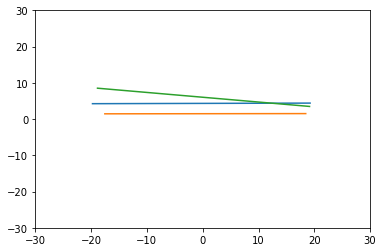

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5999   19.323000
6000   19.488001
6540   18.208000
6541   18.260000
6542   18.254000
...          ...
16615  -0.935000
16616  -0.949000
16617  -0.954000
16618  -0.978000
16619  -1.016000

[1045 rows x 1 columns]
2
       Easting
7432   -17.792
7702    15.024
7703    15.019
7704    14.938
8154    14.320
...        ...
12599   -8.020
12600   -8.001
12601   -8.044
16474    3.755
16475    3.743

[62 rows x 1 columns]
3
         Easting
942    16.353001
1084   16.701000
1085   16.452999
1603   16.190001
6001   19.648001
...          ...
15612  -0.956000
15613  -0.989000
15614  -1.023000
15615  -1.043000
15616  -1.123000

[679 rows x 1 columns]


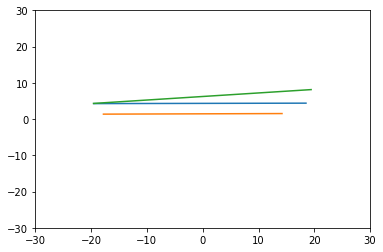

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5727   19.944000
6135   18.820000
6136   18.764000
6737   17.834999
6738   17.329000
...          ...
16978  -0.986000
16979  -1.004000
16980  -1.016000
16981  -1.019000
16982  -1.063000

[1016 rows x 1 columns]
2
         Easting
5725   19.009001
5726   18.988001
6133   17.900000
6134   17.836000
8187  -16.919001
...          ...
14427   5.965000
14428   5.964000
14546   5.756000
14547   5.752000
14548   5.746000

[97 rows x 1 columns]
3
       Easting
926     11.191
927     11.183
1100    11.309
5603    18.166
5728    19.420
...        ...
16014   -1.189
16015   -1.216
16016   -1.264
16017   -1.300
16281   -0.167

[616 rows x 1 columns]


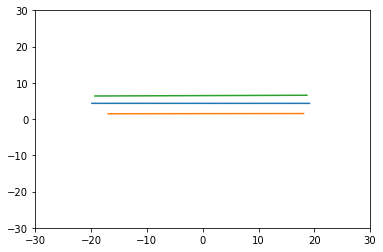

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5925   19.747000
5926   19.893999
6347   18.575001
6348   18.739000
6608  -10.834000
...          ...
17146  -0.872000
17147  -0.883000
17148  -0.909000
17149  -0.927000
17150  -0.957000

[1067 rows x 1 columns]
2
       Easting
7099   -19.837
7276    15.908
7277    15.907
7278    15.924
7483   -18.590
...        ...
17013    3.725
17014    3.722
17015    3.722
17016    3.699
17017    3.699

[139 rows x 1 columns]
3
       Easting
804      5.862
807      5.603
808      5.526
1005     5.400
1178     5.836
...        ...
16047   -0.300
16048   -0.377
16049   -0.400
16050   -0.433
16051   -0.463

[553 rows x 1 columns]


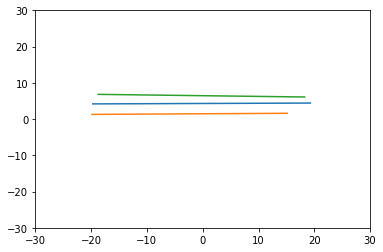

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5490  -16.384001
5491  -16.399000
5787  -16.285000
5788  -16.124001
5789  -16.349001
...          ...
16570  -0.705000
16571  -0.712000
16572  -0.752000
16573  -0.786000
16574  -0.866000

[1105 rows x 1 columns]
2
         Easting
5737   19.854000
5872   18.601999
5873   18.670000
8390  -16.372000
8391  -16.372000
...          ...
13095   6.833000
13096   6.833000
13097   6.822000
13098   6.836000
13099   6.803000

[74 rows x 1 columns]
3
         Easting
764     0.321000
765     0.178000
1618   -0.146000
4702  -16.443001
5090  -16.469999
...          ...
15570  -0.388000
15571  -0.422000
15572  -0.455000
15573  -0.486000
15575  -0.678000

[631 rows x 1 columns]


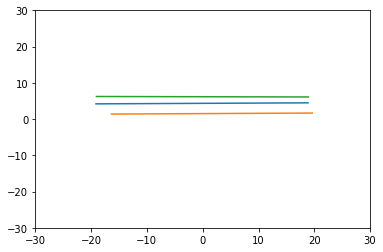

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6247   19.635000
6248   19.599001
6249   19.538000
6694   18.466999
6695   18.445000
...          ...
17370  -0.417000
17371  -0.457000
17372  -0.491000
17373  -0.565000
17374  -0.606000

[1112 rows x 1 columns]
2
         Easting
7302   16.650999
7303   16.614000
7304   16.540001
7463  -19.073000
7464  -18.980000
...          ...
17324   3.676000
17325   3.672000
17326   3.667000
17327   3.671000
17328   3.653000

[209 rows x 1 columns]
3
       Easting
937     -5.317
1325    -5.354
1326    -5.325
1617    -5.529
1923    -5.486
...        ...
16369   -0.649
16370   -0.697
16371   -0.749
16373   -0.860
16374   -0.896

[925 rows x 1 columns]


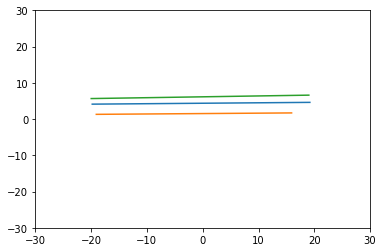

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6620   18.858999
6621   18.841999
7215   17.787001
7216   17.736000
7354  -19.731001
...          ...
16914  -0.952000
16915  -1.038000
17103  -0.071000
17104  -0.193000
17105  -0.309000

[1009 rows x 1 columns]
2
         Easting
6191   18.971001
8691  -16.049999
8692  -15.947000
9181  -15.283000
9182  -15.284000
...          ...
13345   7.492000
13346   7.496000
13347   7.506000
13348   7.463000
16786   3.682000

[73 rows x 1 columns]
3
       Easting
1348   -10.759
1349   -10.934
1643   -10.952
1644   -11.126
1645   -11.152
...        ...
16179   -0.672
16181   -0.745
16182   -0.776
16183   -0.793
16189   -0.987

[957 rows x 1 columns]


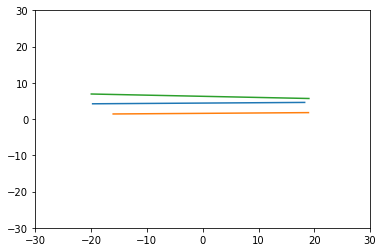

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5300   19.952999
5301   18.278000
5678   18.773001
5679   18.733000
6218   17.738001
...          ...
16175  -0.489000
16176  -0.504000
16177  -0.508000
16178  -0.547000
16179  -0.610000

[1021 rows x 1 columns]
2
         Easting
6215   16.966000
6216   16.954000
6217   17.000000
6367  -18.931999
6548   16.056000
...          ...
16386   3.667000
16387   3.649000
16388   3.655000
16389   3.644000
16390   3.636000

[238 rows x 1 columns]
3
         Easting
1491  -16.625999
1771  -16.749001
1969  -16.749001
1970  -16.789000
3554   16.443001
...          ...
15382  -0.870000
15383  -0.916000
15384  -0.933000
15385  -0.969000
15386  -1.016000

[836 rows x 1 columns]


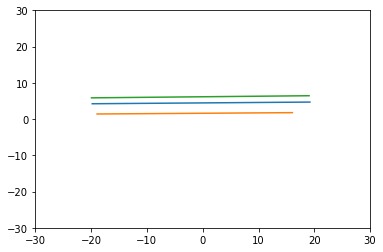

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5372   19.433001
5373   19.365999
5779   18.298000
5780   18.260000
5781   18.207001
...          ...
17930  -0.793000
17931  -0.834000
17932  -0.847000
17933  -0.869000
18336   2.817000

[1084 rows x 1 columns]
2
         Easting
5370   18.714001
5371   18.738001
5775   18.684000
5776   17.655001
5777   17.624001
...          ...
15047   5.658000
15048   5.649000
16203  -5.399000
16204  -5.397000
18085   3.764000

[121 rows x 1 columns]
3
         Easting
4185   16.545000
4547   17.591000
4549   16.618999
4829   16.629000
5374   19.754000
...          ...
17193  -0.403000
17196  -0.537000
17197  -0.567000
17212  -0.967000
17213  -0.985000

[1051 rows x 1 columns]


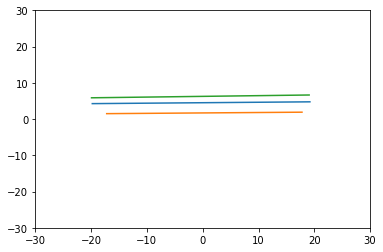

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
4826   17.222000
4827   17.177000
5246   17.093000
5247   16.986000
5521   16.995001
...          ...
17287  -0.729000
17288  -0.738000
17289  -0.773000
17290  -0.805000
17423   0.699000

[934 rows x 1 columns]
2
         Easting
4825   17.287001
5926   17.242001
6435   18.563999
7112  -19.431999
7113  -19.403000
...          ...
17420   3.695000
17421   3.692000
17422   3.635000
17640   3.633000
17641   3.648000

[113 rows x 1 columns]
3
         Easting
2      17.674000
5934   19.455999
6037   19.135000
6038   18.819000
6039   18.874001
...          ...
16663  -0.671000
16664  -0.703000
16666  -0.746000
16667  -0.776000
16668  -0.846000

[1045 rows x 1 columns]


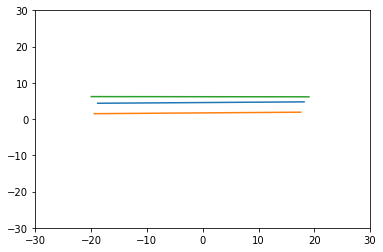

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6082   19.827999
6083   19.941999
6420   18.660999
6421   18.695000
6422   18.558001
...          ...
16707  -0.454000
16708  -0.490000
16709  -0.518000
16826   1.909000
16827   0.949000

[899 rows x 1 columns]
2
         Easting
6080   18.996000
6081   19.222000
6417   17.885000
6418   17.860001
6419   18.028000
...          ...
14200   5.879000
14201   5.869000
14202   5.873000
14336   5.682000
14337   5.675000

[130 rows x 1 columns]
3
         Easting
6423   18.556999
6424   18.511000
6598  -18.868000
7002  -18.591999
7004  -18.952000
...          ...
15819  -0.739000
15820  -0.862000
15821  -0.899000
15822  -0.923000
15823  -0.958000

[834 rows x 1 columns]


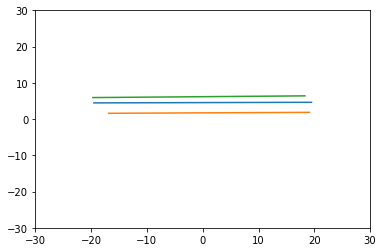

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
4277    16.268
5164    15.410
5165    15.415
5166    15.561
5557    15.207
...        ...
17169   -0.447
17170   -0.490
17171   -0.518
17172   -0.541
17173   -0.597

[784 rows x 1 columns]
2
         Easting
3161   17.569000
3619   17.462000
3994   17.448999
3995   17.389000
4560   17.302999
...          ...
17302   3.724000
17303   3.707000
17304   3.706000
17305   3.704000
17306   3.660000

[189 rows x 1 columns]
3
         Easting
6225   19.940001
6364   19.805000
6365   19.881001
6366   19.164000
6367   19.792000
...          ...
16553  -0.488000
16555  -0.543000
16556  -0.574000
16557  -0.605000
16560  -0.799000

[982 rows x 1 columns]


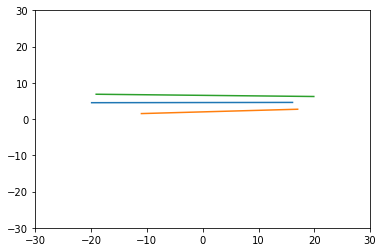

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
5800   -14.838
6078   -14.689
6079   -14.667
6080   -14.618
6081   -14.616
...        ...
17054   -0.504
17055   -0.532
17056   -0.575
17161    1.690
17162   -0.069

[820 rows x 1 columns]
2
       Easting
4727   -14.843
5453   -14.754
5801   -14.652
5802   -14.637
6089   -14.734
...        ...
16993    2.612
16994    2.597
16995    2.590
16996    2.581
16997    2.583

[522 rows x 1 columns]
3
         Easting
0      16.719000
1      16.799999
2      16.535999
3      15.087000
5      15.273000
...          ...
16443  -1.027000
16444  -1.058000
16445  -1.100000
16446  -1.132000
16447  -1.150000

[916 rows x 1 columns]


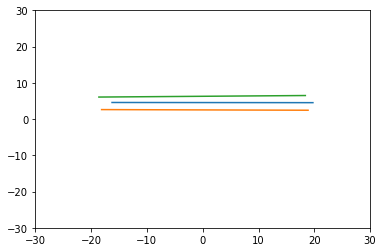

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
4516   -10.082
4878   -10.007
4879    -9.996
4880    -9.993
4881    -9.974
...        ...
17227   -0.891
17228   -0.927
17229   -0.968
17230   -0.988
17558    0.423

[1064 rows x 1 columns]
2
       Easting
4898    -9.965
4899    -9.971
4900    -9.984
4901    -9.985
4902    -9.989
...        ...
11312  -10.687
11345    9.168
11349  -10.059
11350  -10.062
15327    5.498

[174 rows x 1 columns]
3
       Easting
7        7.969
8        7.527
9        7.412
10       7.745
11       7.732
...        ...
16595   -0.322
16596   -0.380
16597   -0.426
16599   -0.480
16601   -0.534

[1028 rows x 1 columns]


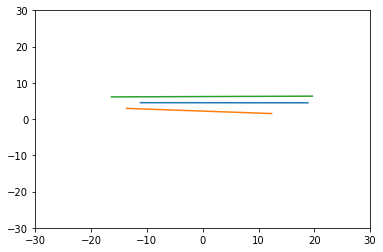

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5607   19.312000
5608   19.490999
5991   18.187000
5992   18.145000
5993   18.378000
...          ...
17813  -0.377000
17814  -0.392000
17815  -0.402000
17816  -0.436000
17817  -0.478000

[1017 rows x 1 columns]
2
         Easting
5605   18.552999
5606   18.541000
5989   17.514000
5990   17.410999
6544   16.593000
...          ...
18065   3.663000
18066   3.665000
18067   3.662000
18068   3.642000
18069   3.628000

[256 rows x 1 columns]
3
       Easting
41       2.026
42       1.957
43       1.985
44       1.930
45       1.872
...        ...
16899   -0.880
16900   -0.907
16901   -0.940
16902   -0.971
16904   -1.154

[1270 rows x 1 columns]


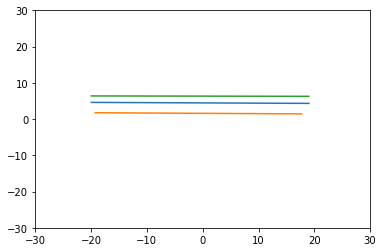

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
3880    18.636
4419    18.584
4420    18.424
4715    18.768
5385    18.782
...        ...
17111   -0.786
17112   -0.796
17113   -0.820
17114   -0.831
17115   -0.873

[1057 rows x 1 columns]
2
       Easting
8911    12.560
8912    12.550
8913    12.551
8914    12.594
9164   -14.134
9165   -14.123
9166   -14.195
9427    12.054
9428    12.044
9429    12.042
9430    12.029
9431    12.029
9684   -13.524
9685   -13.521
9686   -13.465
9936    11.078
9937    11.075
9938    11.063
9939    11.060
10038  -12.378
10039  -12.371
10040  -12.358
10041  -12.359
10253   10.483
10254   10.474
10255   10.468
10256   10.453
10257   10.406
10340  -11.640
10341  -11.631
10342  -11.636
10343  -11.643
10514    9.971
10515    9.970
10516    9.957
10517    9.961
10518    9.923
10644  -11.000
10645  -11.001
10646  -11.012
10647  -11.013
10648  -10.993
10849    9.586
10850    9.587
10851    9.577
10852    9.576
10853    9.539
10868  -10.513
10869  -1

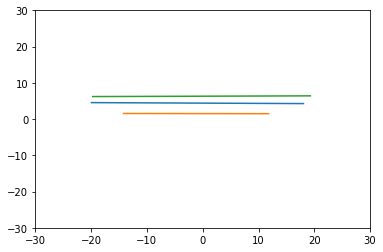

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6096   12.483000
6097   12.047000
6229   19.296000
6230   19.292000
6594   18.158001
...          ...
17508  -0.226000
17509  -0.313000
17510  -0.347000
17511  -0.360000
17512  -0.421000

[1037 rows x 1 columns]
2
         Easting
6227   18.561001
6228   18.646000
6591   17.559999
6592   17.528000
6593   17.542000
...          ...
17493   3.688000
17494   3.685000
17495   3.695000
17496   3.662000
17497   3.660000

[279 rows x 1 columns]
3
       Easting
141     -9.389
142     -9.365
144     -9.519
145     -9.554
146     -9.830
...        ...
16420   -0.392
16427   -0.591
16431   -0.719
16434   -0.789
16435   -0.822

[1155 rows x 1 columns]


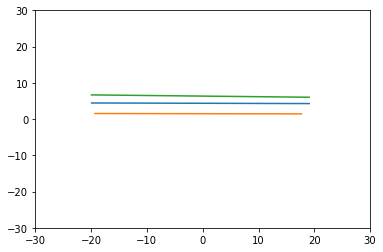

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6249   19.209999
6250   19.287001
6251   19.409000
6615   18.084000
6616   18.062000
...          ...
17109  -0.688000
17110  -0.706000
17111  -0.706000
17112  -0.736000
17113  -0.833000

[1097 rows x 1 columns]
2
       Easting
8460   -16.573
8461   -16.597
9181   -14.826
9270    12.626
9532   -14.267
...        ...
11650    8.304
11651    8.307
11652    8.303
11653    8.289
11654    8.324

[64 rows x 1 columns]
3
       Easting
132    -15.834
134    -15.686
135    -15.529
136    -15.726
435    -15.652
...        ...
16024   -0.917
16025   -0.940
16026   -0.973
16027   -1.002
16028   -1.034

[1113 rows x 1 columns]


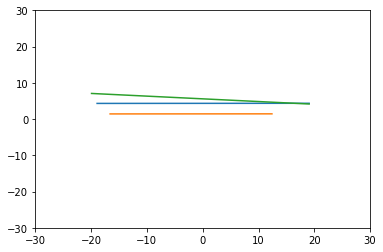

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6067   19.782000
6068   19.862000
6452   18.577999
6453   18.743999
6970   17.480000
...          ...
17396  -0.742000
17397  -0.756000
17398  -0.768000
17399  -0.809000
17400  -0.843000

[1192 rows x 1 columns]
2
         Easting
6448   17.856001
6449   17.837999
6450   17.768000
6451   17.875999
6967   16.867001
...          ...
17280   3.710000
17281   3.729000
17282   3.724000
17283   3.677000
17284   3.698000

[275 rows x 1 columns]
3
         Easting
2381  -17.572001
2680  -17.496000
2681  -17.631001
3475  -11.176000
3481  -17.476999
...          ...
16228  -0.729000
16229  -0.765000
16230  -0.791000
16231  -0.821000
16233  -0.878000

[903 rows x 1 columns]


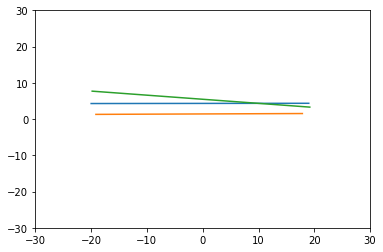

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5616   19.542000
5617   19.482000
5993   18.379000
5994   18.337000
5995   18.483999
...          ...
17012  -0.867000
17013  -0.881000
17014  -0.906000
17015  -0.919000
17016  -0.936000

[1094 rows x 1 columns]
2
         Easting
5540   19.966999
5541   19.968000
7120   15.399000
7716  -16.875999
7717  -16.867001
...          ...
12204   7.717000
12205   7.715000
12206   7.705000
12207   7.712000
12208   7.694000

[70 rows x 1 columns]
3
         Easting
2745  -17.591000
2746  -17.632000
3184  -17.761000
3777  -13.919000
4020  -17.570999
...          ...
15900  -1.223000
15901  -1.253000
15902  -1.276000
15903  -1.312000
15904  -1.323000

[1009 rows x 1 columns]


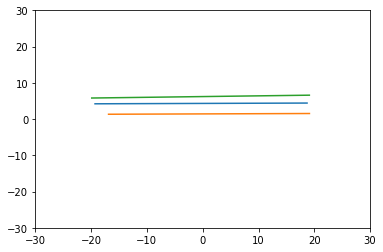

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
4750   -14.090
4751   -14.111
5057    19.441
5058    19.402
5206   -14.097
...        ...
16874   -0.929
16875   -0.946
16876   -0.960
16877   -0.957
16878   -0.997

[1111 rows x 1 columns]
2
         Easting
5393   17.551001
5394   17.554001
5901   17.549000
6066  -19.870001
6067  -19.863001
...          ...
12061  -8.113000
12062  -8.114000
12063  -8.126000
15518   4.375000
16392   3.818000

[78 rows x 1 columns]
3
         Easting
4324   19.365999
4572   19.483999
4573   19.062000
4575   17.958000
4749  -14.120000
...          ...
15652  -1.453000
15653  -1.520000
15654  -1.545000
15655  -1.578000
15978  -0.352000

[1013 rows x 1 columns]


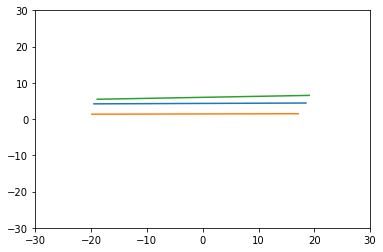

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5270   19.038000
5271   19.209000
5272   19.056000
5627   17.919001
5628   17.955000
...          ...
17908  -0.888000
17909  -0.899000
17910  -0.924000
17911  -0.939000
17912  -1.026000

[1065 rows x 1 columns]
2
         Easting
5153   19.688000
5154   19.745001
5267   18.438000
5268   18.384001
5269   18.389000
...          ...
15991   4.707000
16065   4.627000
16066   4.616000
16067   4.613000
16068   4.578000

[194 rows x 1 columns]
3
         Easting
5155   19.643999
5156   19.448999
5273   18.726999
5274   18.908001
5275   18.562000
...          ...
16656  -1.167000
16657  -1.195000
16658  -1.216000
16659  -1.251000
16666  -1.476000

[1200 rows x 1 columns]


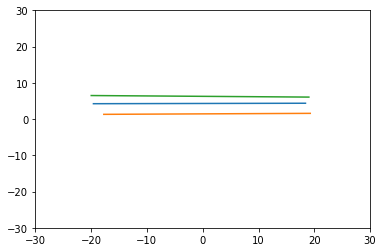

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5735   19.410000
5736   19.403999
5737   19.299000
5738   19.686001
6101   18.231001
...          ...
17162  -0.752000
17163  -0.762000
17164  -0.790000
17165  -0.802000
17166  -0.827000

[1057 rows x 1 columns]
2
       Easting
7264    15.030
8135    13.797
8136    13.749
8137    13.752
8138    13.704
...        ...
11933   -8.704
11934   -8.703
11935   -8.723
11936   -8.706
11937   -8.716

[61 rows x 1 columns]
3
         Easting
4511   19.697001
4513   19.465000
4939   19.194000
5228   19.811001
5229   19.826000
...          ...
16023  -1.402000
16024  -1.416000
16025  -1.454000
16026  -1.467000
16027  -1.501000

[1194 rows x 1 columns]


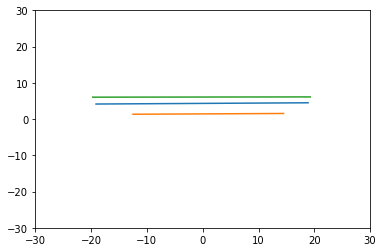

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5515   19.298000
5516   19.247000
5882   17.726000
5883   18.115999
5884   18.073999
...          ...
17086  -0.711000
17087  -0.736000
17088  -0.776000
17089  -0.810000
17090  -0.837000

[1071 rows x 1 columns]
2
         Easting
5418   19.591000
5419   19.532000
5513   18.347000
5514   18.245001
5880   17.304001
...          ...
16433   3.855000
16434   3.854000
16435   3.829000
16619   3.760000
16996   3.705000

[263 rows x 1 columns]
3
         Easting
3563   17.591000
3564   17.625000
3798   17.537001
4069   17.528000
4361   17.753000
...          ...
15971  -1.203000
15972  -1.247000
15973  -1.276000
15974  -1.311000
16284  -0.604000

[1212 rows x 1 columns]


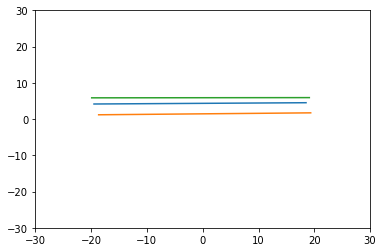

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5551   19.999001
5929   18.774000
5930   18.733999
5931   18.882000
5932   19.084000
...          ...
16979  -0.335000
16980  -0.375000
16981  -0.389000
16982  -0.416000
16983  -0.540000

[974 rows x 1 columns]
2
         Easting
6580  -19.627001
6581  -19.641001
7132   15.199000
7133   15.188000
7134   15.220000
...          ...
16955   3.685000
16956   3.683000
16957   3.677000
16958   3.662000
16959   3.648000

[90 rows x 1 columns]
3
       Easting
4418    13.402
4419    13.389
4420    13.570
4811    13.334
4812    13.355
...        ...
15895   -1.346
15896   -1.380
15898   -1.450
15899   -1.472
15900   -1.504

[1176 rows x 1 columns]


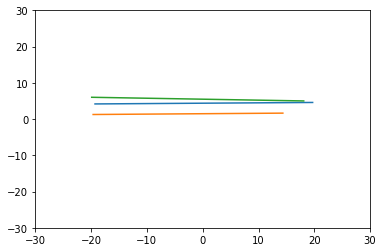

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5470   19.586000
5471   19.629999
5826   18.447001
5827   18.379000
6319   17.448999
...          ...
16852  -2.652000
17071   0.086000
17072  -0.030000
17073  -0.139000
17074  -0.310000

[901 rows x 1 columns]
2
         Easting
5467   18.628000
5468   18.587000
5469   18.549999
5822   17.552999
5823   17.514000
...          ...
17066   3.663000
17067   3.652000
17068   3.653000
17069   3.653000
17070   3.712000

[293 rows x 1 columns]
3
         Easting
5366   19.398001
5473   17.263000
5607  -18.268999
5609  -19.930000
5828   18.927999
...          ...
15961  -1.248000
15962  -1.281000
15963  -1.308000
15964  -1.345000
15965  -1.419000

[1250 rows x 1 columns]


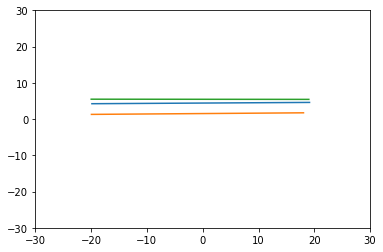

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
5949   19.898001
6339   18.740999
6340   18.802000
6341   18.671000
6342   18.801001
...          ...
17571  -0.565000
17572  -0.575000
17573  -0.605000
17574  -0.606000
17575  -0.636000

[948 rows x 1 columns]
2
       Easting
8431    14.060
8432    14.053
8433    13.992
8855    13.336
8856    13.323
8857    13.341
9097    12.927
9098    12.877
9099    12.870
9100    12.856
9101    13.094
9677    12.367
9678    12.354
9679    12.343
9680    12.334
9681    12.323
9916   -13.371
9917   -13.381
10215   11.338
10216   11.327
10217   11.322
10218   11.307
10306  -12.218
10307  -12.235
10308  -12.211
10565   10.705
10566   10.693
10567   10.688
10568   10.680
10569   10.681
10670  -11.497
10671  -11.509
10672  -11.484
10673  -11.516
10988  -10.861
10989  -10.880
10990  -10.873
10991  -10.881
10992  -10.895
11251  -10.400
11300   -9.927
11458   -9.265
11459   -9.265
11460   -9.280
11461   -9.275
11462   -9.297
11975   -8.895
1

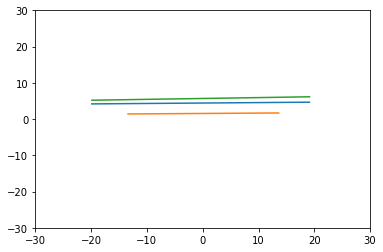

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6174   19.103001
6175   19.039000
6561   18.011999
6562   17.993000
6563   18.055000
...          ...
17371  -0.453000
17372  -0.481000
17373  -0.523000
17374  -0.557000
17375  -0.611000

[905 rows x 1 columns]
2
       Easting
6559    17.399
6560    17.341
7078    16.524
7079    16.427
7218   -19.445
...        ...
17588    3.651
17589    3.643
17590    3.643
17591    3.646
17592    3.630

[270 rows x 1 columns]
3
         Easting
4611   19.875999
4920   19.274000
4921   18.912001
4923   15.663000
5352   19.427999
...          ...
16543  -0.938000
16545  -0.993000
16546  -1.082000
16547  -1.129000
16548  -1.178000

[1262 rows x 1 columns]


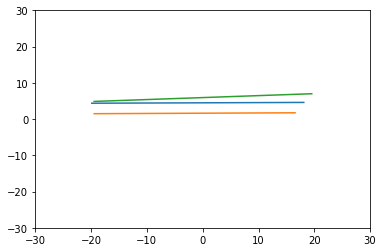

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6280   18.693001
6281   18.753000
6665   17.622000
6666   17.577000
7215   16.660000
...          ...
17351  -0.571000
17352  -0.601000
17353  -0.613000
17354  -0.633000
17355  -0.672000

[900 rows x 1 columns]
2
       Easting
8834    13.391
8835    13.372
8836    13.435
9271    12.737
9272    12.738
9273    12.819
9518    12.349
9519    12.356
9520    12.284
9521    12.316
10160   11.867
10161   11.853
10162   11.844
10163   11.840
10164   11.840
10731   10.910
10732   10.896
10733   10.892
10734   10.883
10735   10.841
10807  -12.789
10808  -12.813
10809  -12.792
10978   10.326
10979   10.321
10980   10.314
10981   10.314
10982   10.283
11044  -11.991
11045  -12.013
11046  -11.997
11047  -12.070
11186    9.823
11187    9.820
11188    9.805
11189    9.808
11190    9.805
11191    9.776
11286  -11.326
11287  -11.334
11288  -11.335
11289  -11.350
11454    9.426
11455    9.425
11456    9.419
11457    9.409
11465  -10.821
1

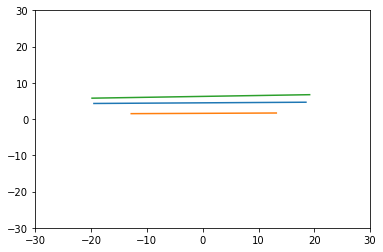

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6486   18.993000
6487   19.034000
6488   18.924999
7036   17.882000
7182  -19.874001
...          ...
16888  -0.284000
16889  -0.311000
16890  -0.354000
16891  -0.452000
16892  -0.494000

[864 rows x 1 columns]
2
         Easting
7184  -18.933001
7185  -18.923000
7346   16.100000
7347   16.174000
7716   15.400000
...          ...
17112   3.660000
17113   3.653000
17114   3.653000
17115   3.631000
17116   3.637000

[194 rows x 1 columns]
3
         Easting
4231   19.927000
4510   19.868000
6075   19.070000
6076   19.760000
6077   18.471001
...          ...
16087  -0.950000
16088  -0.974000
16089  -1.007000
16090  -1.035000
16091  -1.061000

[1321 rows x 1 columns]


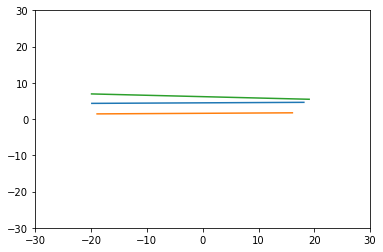

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6069   19.379000
6070   19.343000
6071   19.490999
6450   18.270000
6451   18.216999
...          ...
17077  -0.389000
17078  -0.418000
17079  -0.430000
17080  -0.452000
17081  -0.528000

[916 rows x 1 columns]
2
         Easting
5958   19.738001
5959   19.697001
6066   18.468000
6067   18.441000
6068   18.586000
...          ...
14097   6.044000
14098   6.010000
14390   5.899000
14391   5.901000
17043   3.711000

[103 rows x 1 columns]
3
       Easting
4561    13.537
4856    13.655
4857    13.624
5285    13.588
5286    13.582
...        ...
16256   -0.922
16257   -0.962
16258   -0.983
16259   -1.015
16260   -1.048

[1509 rows x 1 columns]


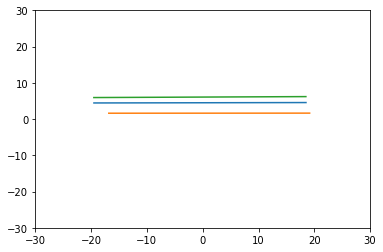

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6169   19.120001
6170   19.077000
6555   17.999001
6556   18.018999
6557   17.948000
...          ...
17683  -0.322000
17684  -0.336000
17685  -0.347000
17686  -0.389000
17687  -0.424000

[949 rows x 1 columns]
2
         Easting
7266  -19.525999
7267  -19.528999
7825   14.908000
7826   14.901000
7827   14.937000
...          ...
17908   3.652000
17909   3.665000
17910   3.642000
17911   3.621000
17912   3.627000

[87 rows x 1 columns]
3
       Easting
2235    19.976
2236    19.921
2521    19.989
2522    19.671
5598    19.944
...        ...
16852   -0.843
16853   -0.866
16854   -0.890
16855   -0.925
16856   -0.944

[1359 rows x 1 columns]


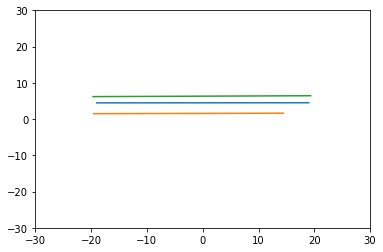

0
Empty DataFrame
Columns: [Easting]
Index: []
1
       Easting
5765    18.990
5766    18.951
5767    19.062
6166    17.878
6167    17.837
...        ...
16802   -1.020
16803   -1.046
16804   -1.072
16805   -1.124
16930   -0.055

[982 rows x 1 columns]
2
         Easting
5647   19.497999
5648   19.485001
5762   18.278000
5763   18.247999
5764   18.235001
...          ...
15674   4.551000
15675   4.555000
15676   4.543000
15677   4.492000
16929   2.933000

[179 rows x 1 columns]
3
         Easting
2356   13.317000
2357   13.357000
2668   18.393999
2670   13.345000
2671   13.268000
...          ...
15896  -0.589000
15899  -0.686000
15900  -0.781000
15901  -0.834000
15902  -1.033000

[1025 rows x 1 columns]


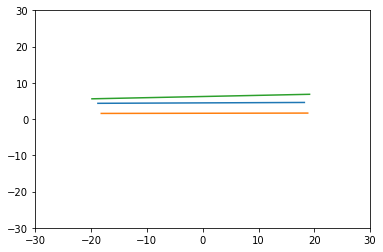

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6012   19.212999
6013   19.254999
6387   18.086000
6388   18.047001
6882   17.113001
...          ...
16833  -0.663000
16834  -0.672000
16835  -0.695000
16836  -0.708000
16837  -0.757000

[1039 rows x 1 columns]
2
         Easting
6009   18.514999
6010   18.476999
6011   18.441999
6383   17.464001
6384   17.436001
...          ...
17049   3.658000
17050   3.651000
17051   3.654000
17052   3.638000
17053   3.685000

[281 rows x 1 columns]
3
         Easting
5903   19.489000
5947  -12.139000
6014   17.358000
6015   17.586000
6016   17.516001
...          ...
15996   0.075000
15997   0.042000
15998   0.011000
16001  -0.076000
16010  -0.383000

[932 rows x 1 columns]


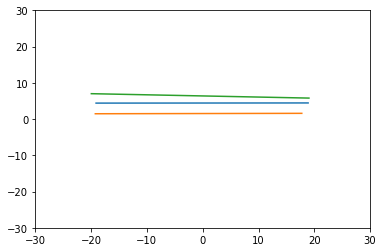

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6283   19.259001
6284   19.218000
6669   18.121000
6670   18.114000
6671   18.084999
...          ...
17131  -0.729000
17132  -0.754000
17133  -0.798000
17134  -0.816000
17135  -0.832000

[965 rows x 1 columns]
2
       Easting
9808   -14.271
9809   -14.274
9810   -14.243
9811   -14.486
10190   12.102
10191   12.096
10192   12.097
10193   12.088
10194   11.968
10398  -13.631
10399  -13.632
10400  -13.680
10718   11.120
10719   11.113
10720   11.122
10721   11.111
10796  -12.471
10797  -12.465
10798  -12.474
10799  -12.494
10930   10.509
10931   10.520
10932   10.511
10933   10.500
10985  -11.723
10986  -11.716
10987  -11.724
10988  -11.742
11115   10.003
11116    9.994
11117   10.005
11118    9.994
11119    9.988
11207  -11.058
11208  -11.070
11209  -11.085
11210  -11.084
11375    9.604
11376    9.609
11377    9.604
11378    9.595
11388  -10.586
11389  -10.621
11407    9.131
11408    9.123
11418    8.625
11419    8.619
1

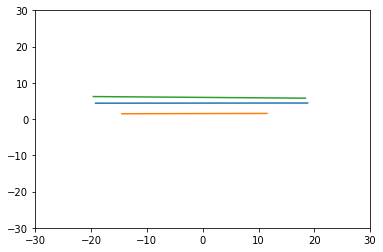

0
Empty DataFrame
Columns: [Easting]
Index: []
1
         Easting
6118   19.457001
6119   19.408001
6120   19.243999
6522   18.297001
6523   18.302000
...          ...
17377  -0.789000
17378  -0.800000
17379  -0.815000
17380  -0.822000
17381  -0.857000

[977 rows x 1 columns]
2
         Easting
7094   16.653000
7095   16.601000
7251  -19.215000
7252  -19.158001
7448   15.791000
...          ...
17577   3.679000
17578   3.678000
17579   3.678000
17580   3.648000
17581   3.648000

[251 rows x 1 columns]
3
       Easting
4112   -12.602
4113   -12.590
4363   -12.992
4364   -13.034
4650   -12.827
...        ...
16548   -0.740
16550   -0.799
16555   -0.948
16556   -0.981
16557   -1.014

[1078 rows x 1 columns]


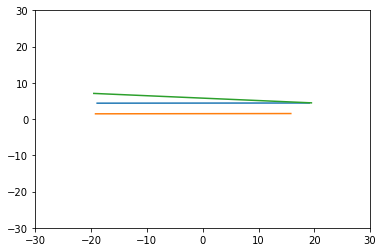

In [42]:
for index in range(0,187):
    data=[]
    try:
        with open('./0926_0027/output_{}.txt'.format(index)) as f:
            line = f.readline()
            while line:
                d=line.split()
                tmp=[]
                for i in d:
                    tmp.append(float(i)) # convert string to float
                data.append(tmp)
                line=f.readline()
    except:
        continue
         
    a=np.array(data)

    ### assumption: There's no void space line in txt file.
    ### intensity: 0~255
    pointcloud_df = pd.DataFrame()
    pointcloud_df["Latitude"] = a[:,0]
    pointcloud_df["Longitude"] = a[:,1]
    pointcloud_df["Altitude"] = a[:,2]
    i = a[:,3]*255
    ii=[]
    for x in i:
        ii.append(int(x))
    pointcloud_df["Intensity"] = ii

    def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
        pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
        pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
        pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
        pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])

        pointcloud_df["Easting"] = pointcloud_df["Latitude"]
        pointcloud_df["Northing"] = pointcloud_df["Longitude"]
        return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

    pointcloud_df["Easting"] = pointcloud_df["Latitude"]
    pointcloud_df["Northing"] = pointcloud_df["Longitude"]
    xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]

    def filter_by_mean_value(pointcloud_df):

        mean = pointcloud_df["Intensity"].mean()
        std = pointcloud_df["Intensity"].std()

        lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
        lanes_df = lanes_df[lanes_df["Intensity"] < mean + 7 * std ]

        return lanes_df

    lanes_df = xyzi_df.copy()
    lanes_df = filter_by_mean_value(lanes_df)
    b = np.array(lanes_df)
    bb = np.vstack((b[:,0], b[:,1],b[:,2]))
    bb= bb.T
    #write_pointcloud("./3original_lane_{}.ply".format(index),bb)
    
    X = lanes_df[["Easting", "Northing", "Altitude"]].values
    Easting=[]
    Northing=[]
    group=[]
    for i in X:
        if i[1]>3 and i[1]<5:
            if i[0]>-20 and i[0]<20:
                Easting.append(i[0])
                Northing.append(i[1])
                group.append(1)
        elif i[1]>-1 and i[1]<3:
            if i[0]>-20 and i[0]<20:
                Easting.append(i[0])
                Northing.append(i[1])
                group.append(2)
        elif i[1]>5 and i[1]<7:
            if i[0]>-20 and i[0]<20:
                Easting.append(i[0])
                Northing.append(i[1])
                group.append(3)
        else:
            Easting.append(i[0])
            Northing.append(i[1])
            group.append(-1)
            
    cluster_df2=pd.DataFrame({"Easting":Easting,"Northing":Northing,"group":group})      
    #print(cluster_df2.head())
    b = np.array(cluster_df2)
    bb = np.vstack((b[:,0], b[:,1],b[:,2]))
    bb= bb.T
    #write_pointcloud("./3original_cluster_{}.ply".format(index),bb)

    ransac = linear_model.RANSACRegressor()
    ransaclines = []

    labels = cluster_df2["group"]
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    cluster_df2 = cluster_df2[cluster_df2["group"]>=0]


    for cluster in range(n_clusters_):
        print(cluster)
        sub_cluster_df = cluster_df2[cluster_df2["group"] == cluster]
        try:
            Xpoints = sub_cluster_df[["Easting"]].values
            Ypoints = sub_cluster_df[["Northing"]].values
            print(sub_cluster_df[["Easting"]])
            #print("Xpoints: ",Xpoints)
            #print("Ypoints: ",Ypoints)
            ransac.fit(Xpoints, Ypoints)
            line_X = np.arange(Xpoints.min(), Xpoints.max())[:, np.newaxis]
            line_y_ransac = ransac.predict(line_X)

            ransaclines.append([line_X,line_y_ransac])
        except:
            continue

    plt.figure()
    plt.xlim(-30,30)
    plt.ylim(-30,30)
    for l in ransaclines:
        plt.plot(l[0],l[1])    

    plt.show()
   # plt.savefig('3savelanefig_{}.png'.format(index))

In [43]:
for i in ransaclines:
    print(i[0],i[1])

[[-18.92200088]
 [-17.92200088]
 [-16.92200088]
 [-15.92200088]
 [-14.92200088]
 [-13.92200088]
 [-12.92200088]
 [-11.92200088]
 [-10.92200088]
 [ -9.92200088]
 [ -8.92200088]
 [ -7.92200088]
 [ -6.92200088]
 [ -5.92200088]
 [ -4.92200088]
 [ -3.92200088]
 [ -2.92200088]
 [ -1.92200088]
 [ -0.92200088]
 [  0.07799912]
 [  1.07799912]
 [  2.07799912]
 [  3.07799912]
 [  4.07799912]
 [  5.07799912]
 [  6.07799912]
 [  7.07799912]
 [  8.07799912]
 [  9.07799912]
 [ 10.07799912]
 [ 11.07799912]
 [ 12.07799912]
 [ 13.07799912]
 [ 14.07799912]
 [ 15.07799912]
 [ 16.07799912]
 [ 17.07799912]
 [ 18.07799912]
 [ 19.07799912]] [[4.38812127]
 [4.38942929]
 [4.39073731]
 [4.39204533]
 [4.39335335]
 [4.39466136]
 [4.39596938]
 [4.3972774 ]
 [4.39858542]
 [4.39989344]
 [4.40120145]
 [4.40250947]
 [4.40381749]
 [4.40512551]
 [4.40643353]
 [4.40774154]
 [4.40904956]
 [4.41035758]
 [4.4116656 ]
 [4.41297362]
 [4.41428163]
 [4.41558965]
 [4.41689767]
 [4.41820569]
 [4.41951371]
 [4.42082173]
 [4.4221297

In [45]:
ransaclines[2][1][len(ransaclines[2][1])-1][0]

4.477199141754215

In [15]:
class Point:
    def __init__(self):
        self.x = 0
        self.y = 0
    def x(self):
        return self._x
    def y(self):
        return self._y

In [30]:
for l,i in enumerate(ransaclines):
    if l==0:
        print("*************** lane 1 ***************")
        point=Point()
        x_list=[]
        y_list=[]
        for idx,j in enumerate(i):
            if idx==0:
                print(j[0][0])
                for k in j:
                    x_list.append(k[0])
                    break
            if idx==1:
                print(j[0][0])
                for k in j:
                    y_list.append(k[0])
                    break
            for p in zip(x_list,y_list):
                point.x=p[0]
                point.y=p[1]

                print(point.x,point.y)
    
    if l==1:
        print("*************** lane 2 ***************")
        point=Point()
        x_list=[]
        y_list=[]
        for idx,j in enumerate(i):
            if idx==0:
                for k in j:
                    x_list.append(k[0])
                    break
            if idx==1:
                for k in j:
                    y_list.append(k[0])
                    break
            for p in zip(x_list,y_list):
                point.x=p[0]
                point.y=p[1]

                print(point.x,point.y)
            

*************** lane 1 ***************
-37.5239982605


IndexError: index 73 is out of bounds for axis 0 with size 1

In [38]:
for i in (ransaclines):
    print(i[0])
    print(i[1])
                

[[-37.52399826]
 [-36.52399826]
 [-35.52399826]
 [-34.52399826]
 [-33.52399826]
 [-32.52399826]
 [-31.52399826]
 [-30.52399826]
 [-29.52399826]
 [-28.52399826]
 [-27.52399826]
 [-26.52399826]
 [-25.52399826]
 [-24.52399826]
 [-23.52399826]
 [-22.52399826]
 [-21.52399826]
 [-20.52399826]
 [-19.52399826]
 [-18.52399826]
 [-17.52399826]
 [-16.52399826]
 [-15.52399826]
 [-14.52399826]
 [-13.52399826]
 [-12.52399826]
 [-11.52399826]
 [-10.52399826]
 [ -9.52399826]
 [ -8.52399826]
 [ -7.52399826]
 [ -6.52399826]
 [ -5.52399826]
 [ -4.52399826]
 [ -3.52399826]
 [ -2.52399826]
 [ -1.52399826]
 [ -0.52399826]
 [  0.47600174]
 [  1.47600174]
 [  2.47600174]
 [  3.47600174]
 [  4.47600174]
 [  5.47600174]
 [  6.47600174]
 [  7.47600174]
 [  8.47600174]
 [  9.47600174]
 [ 10.47600174]
 [ 11.47600174]
 [ 12.47600174]
 [ 13.47600174]
 [ 14.47600174]
 [ 15.47600174]
 [ 16.47600174]
 [ 17.47600174]
 [ 18.47600174]
 [ 19.47600174]
 [ 20.47600174]
 [ 21.47600174]
 [ 22.47600174]
 [ 23.47600174]
 [ 24.47

In [45]:
print(ransaclines)

[[array([[-37.52399826],
       [-36.52399826],
       [-35.52399826],
       [-34.52399826],
       [-33.52399826],
       [-32.52399826],
       [-31.52399826],
       [-30.52399826],
       [-29.52399826],
       [-28.52399826],
       [-27.52399826],
       [-26.52399826],
       [-25.52399826],
       [-24.52399826],
       [-23.52399826],
       [-22.52399826],
       [-21.52399826],
       [-20.52399826],
       [-19.52399826],
       [-18.52399826],
       [-17.52399826],
       [-16.52399826],
       [-15.52399826],
       [-14.52399826],
       [-13.52399826],
       [-12.52399826],
       [-11.52399826],
       [-10.52399826],
       [ -9.52399826],
       [ -8.52399826],
       [ -7.52399826],
       [ -6.52399826],
       [ -5.52399826],
       [ -4.52399826],
       [ -3.52399826],
       [ -2.52399826],
       [ -1.52399826],
       [ -0.52399826],
       [  0.47600174],
       [  1.47600174],
       [  2.47600174],
       [  3.47600174],
       [  4.47600174],
       [ 

In [59]:
lane1startx=ransaclines[0][0][0][0]
lane1starty=ransaclines[0][1][0][0]
lane1endx=ransaclines[0][0][len(ransaclines[0][0])-1][0]
lane1endy=ransaclines[0][1][len(ransaclines[0][1])-1][0]

lane2startx=ransaclines[1][0][0][0]
lane2starty=ransaclines[1][1][0][0]
lane2endx=ransaclines[1][0][len(ransaclines[1][0])-1][0]
lane2endy=ransaclines[1][1][len(ransaclines[1][1])-1][0]



-37.5239982605 10.511888925946561
35.4760017395 9.601042228880498
-67.6360015869 -3.2226097365701087
34.363998413100006 -1.031814015252727


In [163]:
sub_cluster_df["Easting"]

Series([], Name: Easting, dtype: float64)

In [148]:
data=[]
with open('./output_1.txt') as f:
    line = f.readline()
    while line:
        d=line.split()
        tmp=[]
        for i in d:
            tmp.append(float(i)) # convert string to float
        data.append(tmp)
        line=f.readline()

In [149]:
a=np.array(data)

### assumption: There's no void space line in txt file.
### intensity: 0~255
pointcloud_df = pd.DataFrame()
pointcloud_df["Latitude"] = a[:,0]
pointcloud_df["Longitude"] = a[:,1]
pointcloud_df["Altitude"] = a[:,2]
i = a[:,3]*255
ii=[]
for x in i:
    ii.append(int(x))
pointcloud_df["Intensity"] = ii

In [120]:
b = np.vstack((a[:,0], a[:,1],a[:,2]))
b= b.T
write_pointcloud("./original.ply",b)

In [121]:
def convert_fuse(pointcloud_df, min_x = 0.0, min_y = 0.0, min_z = 0.0):
    pointcloud_df["Latitude"] = pd.to_numeric(pointcloud_df["Latitude"])
    pointcloud_df["Longitude"] = pd.to_numeric(pointcloud_df["Longitude"])
    pointcloud_df["Altitude"] = pd.to_numeric(pointcloud_df["Altitude"])
    pointcloud_df["Intensity"] = pd.to_numeric(pointcloud_df["Intensity"])
    
    pointcloud_df["Easting"] = pointcloud_df["Latitude"]
    pointcloud_df["Northing"] = pointcloud_df["Longitude"]
    return pointcloud_df, (min_x, min_y, min_z), (zone_number, zone_letter)

In [122]:
#pointcloud_df, (min_x, min_y, min_z), (number, letter) = convert_fuse(pointcloud_df)

In [123]:
pointcloud_df["Easting"] = pointcloud_df["Latitude"]
pointcloud_df["Northing"] = pointcloud_df["Longitude"]

In [125]:
xyzi_df = pointcloud_df[["Easting", "Northing", "Altitude", "Intensity"]]
xyzi_df.to_csv("./pointcloud.xyz", sep=" ", header=False, index=False)
xyzi_df.head()



,Easting,Northing,Altitude,Intensity
0,56.741001,8.468,2.149,0
1,56.366001,8.502,2.137,0
2,55.846001,8.782,2.121,0
3,71.956001,12.020,2.676,0
4,74.141998,12.505,2.752,0


In [126]:
b = np.array(pointcloud_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original.ply",bb)

## 2. Pointcloud Filtering

1. remove noise (too high or too low intensity)
2. set an adaptive threshold. (lane marking points have a higher intensity value)

In [127]:
def filter_by_mean_value(pointcloud_df):

    mean = pointcloud_df["Intensity"].mean()
    std = pointcloud_df["Intensity"].std()

    lanes_df = pointcloud_df[pointcloud_df["Intensity"] > mean + 1 * std]
    lanes_df = lanes_df[lanes_df["Intensity"] < mean + 7 * std ]
    
    print("MEAN FILTER:")
    print("============")
    print("Intensity - Mean value:      ", mean)
    print("Intensity - Std value:       ", std)
    print("Intensity - Lower bound:     ", mean + 1 * std)
    print("Intensity - Upper bound:     ", mean + 9 * std)
    print("Intensity - Filtered points: ", len(lanes_df))
    print("Intensity - Original points: ", len(pointcloud_df))
    print("Intensity - Reduction to %:  ", len(lanes_df)/len(pointcloud_df))
    
    return lanes_df

In [128]:
lanes_df = xyzi_df.copy()
lanes_df = filter_by_mean_value(lanes_df)
lanes_df[['Easting', 'Northing', 'Altitude', 'Intensity']].to_csv("./filter_mean.xyz", index=False)

MEAN FILTER:
Intensity - Mean value:       17256.62350966917
Intensity - Std value:        10871.95928095454
Intensity - Lower bound:      28128.58279062371
Intensity - Upper bound:      115104.25703826002
Intensity - Filtered points:  17141
Intensity - Original points:  125140
Intensity - Reduction to %:   0.13697458846092375


In [129]:
b = np.array(lanes_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original_lane.ply",bb)

## 3. Lane Marking Detection

In [158]:
X = lanes_df[["Easting", "Northing", "Altitude"]].values
print(len(X))

12968


In [172]:
for i in lanes_df[["Easting", "Northing", "Altitude"]]:
    print(i)
    if i[1]>9 and i[1]<11:
        lanes_df["group"] = 1
    elif i[1]>-1 and i[1]<1:
        lanes_df["group"] = 2
    elif i[1]>-5 and i[1]<-11:
        lanes_df["group"] = 3
    else:
        lanes_df["group"] = -1
    break

Easting


TypeError: '>' not supported between instances of 'str' and 'int'

In [181]:
X = lanes_df[["Easting", "Northing", "Altitude"]].values

db = DBSCAN(eps=1, min_samples=30).fit(X)

labels = db.labels_
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

In [182]:
lanes_df["Group"] = labels
cluster_df = lanes_df[["Easting", "Northing", "Altitude", "Group"]]
cluster_df = cluster_df[cluster_df["Group"]>=0]
#cluster_df.to_csv("./clustering.xyz",index=False
b = np.array(cluster_df)
bb = np.vstack((b[:,0], b[:,1],b[:,2]))
bb= bb.T
write_pointcloud("./original_cluster.ply",bb)

In [183]:
print(lanes_df["Easting"].max())
print(lanes_df["Easting"].min())
print(lanes_df["Easting"].mean())
print("---------------------------")
print(lanes_df["Northing"].max())
print(lanes_df["Northing"].min())
print(lanes_df["Northing"].mean())

58.9370002747
-42.4539985657
0.05836298446910307
---------------------------
28.5760002136
-26.2430000305
0.16643352060937822


In [184]:
from sklearn import linear_model
ransac = linear_model.RANSACRegressor()
ransaclines = []

for cluster in range(n_clusters_):
    sub_cluster_df = cluster_df[cluster_df["Group"] == cluster]
    Xpoints = sub_cluster_df[["Easting"]].values
    Ypoints = sub_cluster_df[["Northing"]].values
    print("Xpoints: ", Xpoints)
    print("Ypoints: ",Ypoints)
    ransac.fit(Xpoints, Ypoints)
    line_X = np.arange(Xpoints.min(), Xpoints.max())[:, np.newaxis]
    line_y_ransac = ransac.predict(line_X)

    ransaclines.append([line_X,line_y_ransac])

Xpoints:  [[12.14999962]
 [12.16600037]
 [10.3579998 ]
 ...
 [-0.83200002]
 [-0.84600002]
 [-0.87599999]]
Ypoints:  [[11.11200047]
 [11.30300045]
 [ 9.80099964]
 ...
 [ 4.38700008]
 [ 4.3829999 ]
 [ 4.43100023]]
Xpoints:  [[-7.71799994]
 [-7.78999996]
 [-7.87400007]
 [-7.96500015]
 [-8.04899979]
 [-7.70499992]
 [-7.76100016]
 [-7.85300016]
 [-7.96299982]
 [-7.8130002 ]
 [-7.98699999]
 [-7.6960001 ]
 [-7.76399994]
 [-7.86600018]
 [-7.84299994]
 [-7.66599989]
 [-7.73199987]
 [-8.04399967]
 [-7.64400005]
 [-7.72800016]
 [-7.77199984]
 [-7.8579998 ]
 [-7.91599989]
 [-7.69000006]
 [-7.77899981]
 [-7.86800003]
 [-7.63600016]
 [-7.67799997]
 [-7.76200008]
 [-7.86499977]
 [-7.62400007]
 [-7.7579999 ]
 [-7.88899994]
 [-7.69299984]
 [-7.77299976]
 [-7.86299992]
 [-7.94199991]
 [-5.11399984]
 [-6.7420001 ]
 [-7.53900003]
 [-7.65299988]
 [-7.69199991]
 [-7.7329998 ]
 [-7.83900023]
 [-7.91200018]
 [-4.91499996]
 [-5.08400011]
 [-6.59399986]
 [-7.57399988]
 [-7.60500002]
 [-7.62300014]
 [-7.66499996

Xpoints:  [[17.34799957]
 [18.25499916]
 [18.02400017]
 [17.27400017]
 [18.29700088]
 [18.18000031]
 [18.59799957]
 [18.59499931]
 [18.53300095]
 [18.59700012]
 [18.72599983]
 [17.86000061]
 [17.89100075]
 [18.02499962]
 [18.32900047]
 [18.39699936]
 [18.61199951]
 [18.78300095]
 [17.82900047]
 [18.05800056]
 [18.84000015]
 [18.32900047]
 [17.58099937]
 [17.98999977]
 [17.92200088]
 [17.29199982]
 [17.35899925]
 [17.72200012]
 [17.35300064]
 [17.24099922]
 [17.25200081]
 [17.1760006 ]
 [17.77499962]
 [17.30800056]
 [17.30699921]
 [17.42200088]
 [17.62899971]
 [16.88899994]]
Ypoints:  [[-5.22399998]
 [-6.3130002 ]
 [-6.01999998]
 [-5.87699986]
 [-5.80999994]
 [-5.64799976]
 [-5.42600012]
 [-5.204     ]
 [-5.0619998 ]
 [-5.01599979]
 [-4.83099985]
 [-5.94500017]
 [-5.67600012]
 [-5.50099993]
 [-5.1880002 ]
 [-4.86499977]
 [-4.73500013]
 [-4.65299988]
 [-5.59200001]
 [-5.5079999 ]
 [-5.19999981]
 [-4.59800005]
 [-6.16200018]
 [-5.27600002]
 [-5.04300022]
 [-5.51399994]
 [-5.41499996]
 [-5

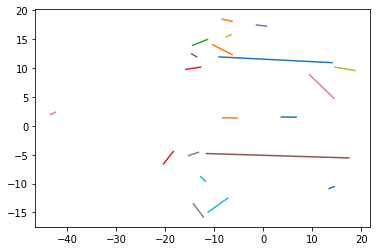

Number of prototype lane markings:  22


In [153]:
#plt.figure(figsize=(20,10))
#plt.xlim(-30,30)
#plt.ylim(-30,30)

#for l in ransaclines:
#    plt.plot(l[0], l[1])
    
for l in ransaclines:
    plt.plot(l[0],l[1])

    
plt.show()
print("Number of prototype lane markings: ", len(ransaclines))

1. change clustering algorithm(no dbscan)
2. remove noise
3. line fitting algorithm

In [97]:
lanelength=[]
for l in ransaclines:
    lanelength.append(len(l[0]))

In [98]:
lanelength

[27, 25, 3, 1, 5, 4, 5, 6, 1, 4, 4, 2, 2, 3, 2, 3, 3, 3, 3, 3, 2]

In [99]:
lane1idx=lanelength.index(max(lanelength))

In [100]:
lanelength[lane1idx]=-1
lane2idx=lanelength.index(max(lanelength))

In [101]:
print(lane1idx)
print(lane2idx)

0
1


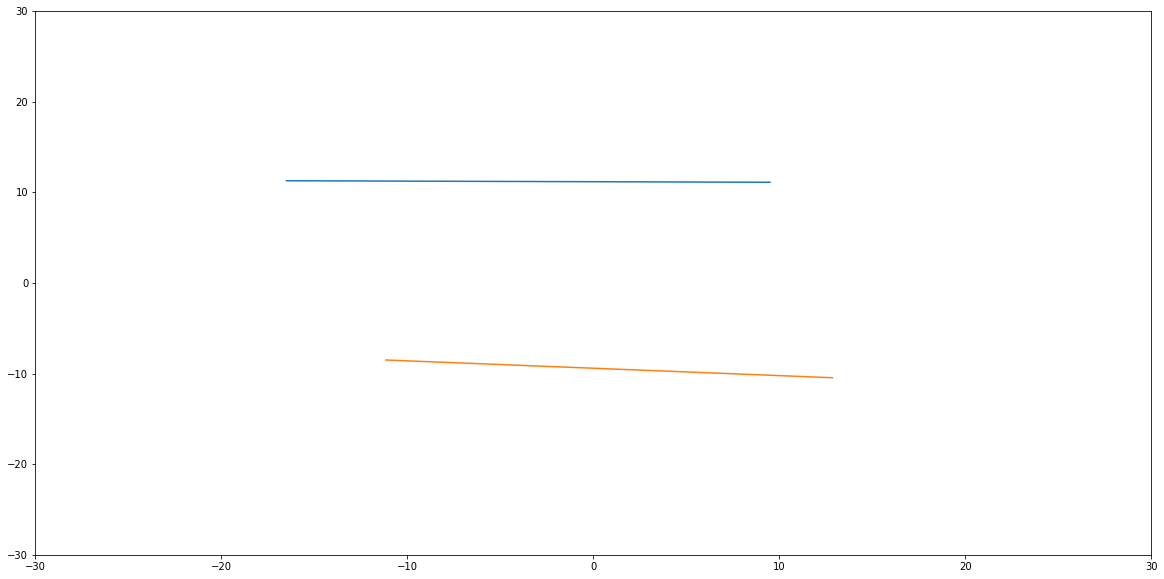

Number of prototype lane markings:  21


In [102]:
plt.figure(figsize=(20,10))
plt.xlim(-30,30)
plt.ylim(-30,30)

#for l in ransaclines:
#    plt.plot(l[0], l[1])
    
plt.plot(ransaclines[lane1idx][0], ransaclines[lane1idx][1])
plt.plot(ransaclines[lane2idx][0], ransaclines[lane2idx][1])

    
plt.show()
print("Number of prototype lane markings: ", len(ransaclines))

In [103]:
print(ransaclines[lane1idx][0][0], ransaclines[lane1idx][1][0])
print(ransaclines[lane1idx][0][len(ransaclines[lane1idx][0])-1], ransaclines[lane1idx][1][len(ransaclines[lane1idx][1])-1])

print(ransaclines[lane2idx][0][0], ransaclines[lane2idx][1][0])
print(ransaclines[lane2idx][0][len(ransaclines[lane2idx][0])-1], ransaclines[lane2idx][1][len(ransaclines[lane2idx][1])-1])

[-16.49200058] [11.28559843]
[9.50799942] [11.1182006]
[-11.14299965] [-8.49904109]
[12.85700035] [-10.45523971]


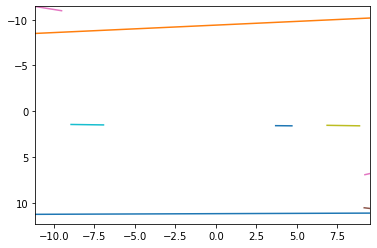

In [104]:
roileft=max(ransaclines[lane1idx][0][0],ransaclines[lane2idx][0][0])
roiright=min(ransaclines[lane1idx][0][len(ransaclines[lane1idx][0])-1],ransaclines[lane2idx][0][len(ransaclines[lane2idx][0])-1])
roiup=max(ransaclines[lane1idx][1][0],ransaclines[lane1idx][1][len(ransaclines[lane1idx][1])-1])+1
roidown=min(ransaclines[lane2idx][1][0],ransaclines[lane2idx][1][len(ransaclines[lane2idx][1])-1])-1

plt.xlim(roileft,roiright)
plt.ylim(roiup,roidown)
for l in ransaclines:
    plt.plot(l[0],l[1])
plt.show()